# Aviation Risk Analysis


##  Introduction
Aviation risk analysis quantifies safety and operational risks to support investment decisions. For an investor considering entry into the aviation sector (airline, regional operator, leasing/maintenance business, airport infrastructure, or aggregator), sound analysis must combine data cleaning, exploratory data analysis (to surface patterns and root causes), statistical modelling (to quantify factors that raise or lower risk), and business-context recommendations (commercial, regulatory, insurance, and safety controls).

This project will

- Clean and validate the accident/incident dataset (from Kaggle) you provided.
- Explore and model underlying causes and risk drivers (phase-of-flight, weather, location, aircraft type, operator, time trends).
- Provide concrete recommendations targeted to a company planning to invest in aviation.

# 1.0 Business Understanding
## 1.1 Overview of the Aviation 
The aviation industry provides passenger transport, cargo movement, aircraft operations, maintenance services, and airport infrastructure. It is a globally connected sector that supports trade, tourism, logistics, and economic mobility. Despite being safety-sensitive and highly regulated, aviation remains an essential industry with consistent long-term demand.

Why a Company Would Invest in Aviation         
**Growing demand**  Passenger travel and air cargo continue to expand globally, supported by rising incomes and increased cross-border movement.                
**Multiple investment options** Airlines, aircraft leasing, cargo operations, airport infrastructure, and maintenance (MRO) all offer distinct revenue models.              
**High entry barriers** Regulation, capital requirements, and operational expertise reduce competition and create stable market positions for established players.                    
**Technological improvements** Modern aircraft, automation, and digital maintenance systems reduce operating costs and enhance safety.                 
**Strategic importance** Aviation enables economic activity and often benefits from government support through partnerships or incentives.
               
These factors make aviation attractive for investors seeking long-term returns, diversification, and exposure to essential global infrastructure, provided safety risks are well understood.

## 1.2 Main   Objetive
Use historical aviation accident data to identify key risk drivers and generate clear, evidence-based recommendations for a company considering investment in the aviation sector.

## 1.3 Specific objectives
- Clean and prepare the dataset for accurate analysis. 
- Identify trends and patterns in accidents and fatalities.
- Determine which operational and environmental factors contribute most to aviation risk.
- Quantify risks to highlight safer and riskier aviation segments.
- Provide actionable recommendations that guide investment decisions.

## 1.4 Stakeholders
- Investors and company executives
- Risk and compliance teams
- Aviation operations and safety experts
- Regulators and insurers

## 1.5 Success Criteria
- A clean, reliable dataset with well-defined variables
- Clear ranking of major risk factors
- Accurate analysis supported by measurable indicators
- Recommendations that directly inform investment decisions


# 2.0 Data Understanding
## 2.1 Dataset Overview
- Total Records: 88,889
- Total Variables: 31
- Time Span: Multiple decades of global aviation accident/incident data
- Source: Kaggle – Aviation Accident Database

The dataset contains event identifiers, aircraft details, operational context, injury outcomes, and investigative information. It is extensive enough to identify historical patterns, risk drivers, and operational conditions linked to aviation safety.

## 2.2 Key Variable Categories
**Event Information**
Event.Id, Accident.Number, Event.Date, Location, Country, Report.Status, Publication.Date
**Operational Context**
Investigation.Type, Airport.Code, Airport.Name, FAR.Description, Purpose.of.flight, Weather.Condition, Broad.phase.of.flight
**Aircraft Information**
Make, Model, Registration.Number, Number.of.Engines, Engine.Type, Aircraft.damage, Aircraft.Category
**Injury Outcomes**
Injury.Severity, Total.Fatal.Injuries, Total.Serious.Injuries, Total.Minor.Injuries, Total.Uninjured
**Geolocation**
Latitude, Longitude

These variables among others, enable analysis of when, where, and why accidents occur, and which factors most influence severity.


To have a clearer understanding we start by importing the libraries, load the dataset and inspect it at depth to uncover all the hidden aspects that cannot be seen on the surface.

In [1]:
#importing libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100000)
import warnings
warnings.filterwarnings('ignore')

In [2]:
#loading the dataset and asinging it to data then displaying the head
data=pd.read_csv("aviation_dataset/AviationData.csv",encoding='latin-1',low_memory=False)

data.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Schedule,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,NC6404,Stinson,108-3,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,Fatal(4),Destroyed,NaN,N5069P,Piper,PA24-180,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,Fatal(3),Destroyed,NaN,N5142R,Cessna,172M,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,N1168J,Rockwell,112,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,Fatal(1),Destroyed,NaN,N15NY,Cessna,501,No,NaN,NaN,NaN,NaN,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


#### 2.2.1 Understanding the dataset in depth

In [3]:
#inspecting
data.shape

(88889, 31)

The Dataset has 88,889 recods each has 31 entries

In [4]:
#exploring the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

In [5]:
# Previewing the columns in the dataset
data.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [6]:
# Previewing datatypes
data.dtypes

Event.Id                   object
Investigation.Type         object
Accident.Number            object
Event.Date                 object
Location                   object
Country                    object
Latitude                   object
Longitude                  object
Airport.Code               object
Airport.Name               object
Injury.Severity            object
Aircraft.damage            object
Aircraft.Category          object
Registration.Number        object
Make                       object
Model                      object
Amateur.Built              object
Number.of.Engines         float64
Engine.Type                object
FAR.Description            object
Schedule                   object
Purpose.of.flight          object
Air.carrier                object
Total.Fatal.Injuries      float64
Total.Serious.Injuries    float64
Total.Minor.Injuries      float64
Total.Uninjured           float64
Weather.Condition          object
Broad.phase.of.flight      object
Report.Status 

## 2.3 Sanity Check

In [7]:
data.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Schedule,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,NC6404,Stinson,108-3,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,Fatal(4),Destroyed,NaN,N5069P,Piper,PA24-180,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,Fatal(3),Destroyed,NaN,N5142R,Cessna,172M,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,N1168J,Rockwell,112,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,Fatal(1),Destroyed,NaN,N15NY,Cessna,501,No,NaN,NaN,NaN,NaN,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [3]:
#droping columns not so helpful in my analysis and with huge missing amounts of values - identifying them
columns_to_drop=['Event.Id',
                'Accident.Number',
                'Registration.Number',
                'Latitude',
                'Longitude',
                'Airport.Code',
                'Airport.Name',
                'Report.Status',
                'Publication.Date']

In [4]:
data = data.drop(columns=columns_to_drop, axis=1)

In [5]:
# Converting event data to data
data['Event.Date'] = pd.to_datetime(data['Event.Date'])

In [6]:
# Renaming the columns for easier analysis and visualization
rename_cols = {
    "Investigation.Type": "investigation_type",
    "Event.Date": "event_date",
    "Location": "location",
    "Country": "country",
    "Injury.Severity": "injury_severity",
    "Aircraft.damage": "aircraft_damage",
    "Aircraft.Category": "aircraft_category",
    "Make": "make",
    "Model": "model",
    "Amateur.Built": "amateur_built",
    "Number.of.Engines": "num_engines",
    "Engine.Type": "engine_type",
    "FAR.Description": "far_description",
    "Schedule": "schedule",
    "Purpose.of.flight": "purpose_of_flight",
    "Air.carrier": "air_carrier",
    "Total.Fatal.Injuries": "fatal_injuries",
    "Total.Serious.Injuries": "serious_injuries",
    "Total.Minor.Injuries": "minor_injuries",
    "Total.Uninjured": "uninjured",
    "Weather.Condition": "weather_condition",
    "Broad.phase.of.flight": "phase_of_flight"
}


In [7]:
data = data.rename(columns=rename_cols)

In [13]:
# Checking for duplication of records
data.loc[data.duplicated()]

,investigation_type,event_date,location,country,injury_severity,aircraft_damage,aircraft_category,make,model,amateur_built,num_engines,engine_type,far_description,schedule,purpose_of_flight,air_carrier,fatal_injuries,serious_injuries,minor_injuries,uninjured,weather_condition,phase_of_flight
1371,Accident,1982-05-28,"EVANSVILLE, IN",United States,Non-Fatal,Substantial,Airplane,Cessna,172,No,1.0,Reciprocating,Part 91: General Aviation,NaN,Personal,NaN,0.0,0.0,0.0,7.0,VMC,Cruise
4761,Accident,1983-05-22,"BRIDGEPORT, CA",United States,Fatal(1),Substantial,NaN,Schempp-hirth,STANDARD CIRRUS,No,NaN,Unknown,NaN,NaN,Unknown,NaN,1.0,0.0,0.0,1.0,VMC,Cruise
7941,Accident,1984-04-13,"DELAND, FL",United States,Non-Fatal,Substantial,NaN,Cessna,172P,No,1.0,Reciprocating,NaN,NaN,Instructional,NaN,0.0,0.0,0.0,2.0,VMC,Taxi
8661,Accident,1984-06-18,"PORTLAND, AR",United States,Non-Fatal,Substantial,NaN,Snow,AT400,No,1.0,Turbo Prop,NaN,UNK,Aerial Application,NaN,0.0,0.0,0.0,2.0,VMC,Landing
19820,Incident,1988-03-10,"GREENSBORO, NC",United States,Incident,NaN,NaN,Boeing,737,No,2.0,Turbo Fan,NaN,SCHD,Unknown,Continental Airlines (dba: Texas Int'l Airline...,0.0,0.0,0.0,159.0,VMC,Maneuvering
21077,Incident,1988-08-05,"ATLANTA, GA",United States,Incident,Minor,NaN,Douglas,DC-9-51,No,2.0,Turbo Fan,NaN,SCHD,Unknown,NaN,0.0,0.0,0.0,199.0,UNK,Taxi
24878,Accident,1990-02-09,"TETERBORO, NJ",United States,Non-Fatal,Substantial,NaN,Mitsubishi,MU-2B-35,No,2.0,Turbo Prop,NaN,NSCH,Unknown,Epps Air Service,0.0,0.0,0.0,2.0,VMC,Taxi
26868,Accident,1990-10-20,"KENT, OH",United States,Non-Fatal,Substantial,NaN,Cessna,152,No,1.0,Reciprocating,NaN,NaN,Instructional,NaN,0.0,0.0,0.0,2.0,VMC,Approach
27496,Accident,1991-03-02,"MARANA, AZ",United States,Non-Fatal,Substantial,NaN,Boeing,A75,No,1.0,Reciprocating,NaN,NaN,Other Work Use,NaN,0.0,0.0,0.0,3.0,VMC,Maneuvering
27811,Accident,1991-04-19,"SANTA ROSA, NM",United States,Non-Fatal,Substantial,NaN,Ercoupe (eng & Research Corp.),415-C,Yes,1.0,Reciprocating,NaN,NaN,Personal,NaN,0.0,0.0,1.0,1.0,VMC,Climb


In [14]:
#data.loc[data.duplicated(subset=['investigation_type','event_date'])]

The result above are not exact identical so we wont be droping them.

In [15]:
# Checking duplicated subsets
# data.query('Model == "172"')
# if duplicated we can try and revesrse it by data = data.loc[~data.duplicated(subset=['Model'])].reset_index(drop=True).copy()

In [16]:
#checking for missing values
data.isna().sum()

investigation_type        0
event_date                0
location                 52
country                 226
injury_severity        1000
aircraft_damage        3194
aircraft_category     56602
make                     63
model                    92
amateur_built           102
num_engines            6084
engine_type            7096
far_description       56866
schedule              76307
purpose_of_flight      6192
air_carrier           72241
fatal_injuries        11401
serious_injuries      12510
minor_injuries        11933
uninjured              5912
weather_condition      4492
phase_of_flight       27165
dtype: int64

In [17]:
#checking for the % of misssing data
data.isna().mean()*100

investigation_type     0.000000
event_date             0.000000
location               0.058500
country                0.254250
injury_severity        1.124999
aircraft_damage        3.593246
aircraft_category     63.677170
make                   0.070875
model                  0.103500
amateur_built          0.114750
num_engines            6.844491
engine_type            7.982990
far_description       63.974170
schedule              85.845268
purpose_of_flight      6.965991
air_carrier           81.271023
fatal_injuries        12.826109
serious_injuries      14.073732
minor_injuries        13.424608
uninjured              6.650992
weather_condition      5.053494
phase_of_flight       30.560587
dtype: float64

In [8]:
# Futher droping columns with high missingness and with low value to the analysis
cols_to_drop = ['air_carrier','schedule','far_description']
data = data.drop(columns=cols_to_drop, axis=1)

In [9]:
# Identifying garbage values
for i in data.select_dtypes(include='object').columns:
    print(data[i].value_counts())
    print("'''"*10)

investigation_type
Accident    85015
Incident     3874
Name: count, dtype: int64
''''''''''''''''''''''''''''''
location
ANCHORAGE, AK                                                      434
MIAMI, FL                                                          200
ALBUQUERQUE, NM                                                    196
HOUSTON, TX                                                        193
CHICAGO, IL                                                        184
FAIRBANKS, AK                                                      174
TUCSON, AZ                                                         142
PHOENIX, AZ                                                        132
ORLANDO, FL                                                        132
ENGLEWOOD, CO                                                      131
SAN DIEGO, CA                                                      119
JACKSONVILLE, FL                                                   119
Anchorage, AK              

### 2.3.1 Feature Understanding
Plotting feature distribution   
Histogram. KDE, baxplot

#### 2.3.1.1 Univariate Analysis

In [10]:
# Data distribution
data.describe()

,event_date,num_engines,fatal_injuries,serious_injuries,minor_injuries,uninjured
count,88889,82805.000000,77488.000000,76379.000000,76956.000000,82977.000000
mean,1999-09-17 17:13:39.354475904,1.146585,0.647855,0.279881,0.357061,5.325440
min,1948-10-24 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1989-01-15 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1998-07-18 00:00:00,1.000000,0.000000,0.000000,0.000000,1.000000
75%,2009-07-01 00:00:00,1.000000,0.000000,0.000000,0.000000,2.000000
max,2022-12-29 00:00:00,8.000000,349.000000,161.000000,380.000000,699.000000
std,NaN,0.446510,5.485960,1.544084,2.235625,27.913634


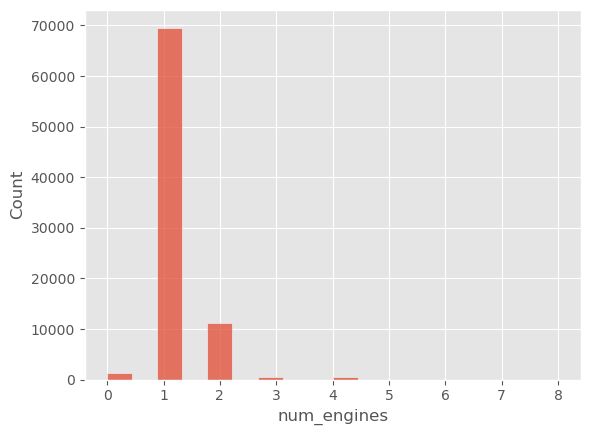

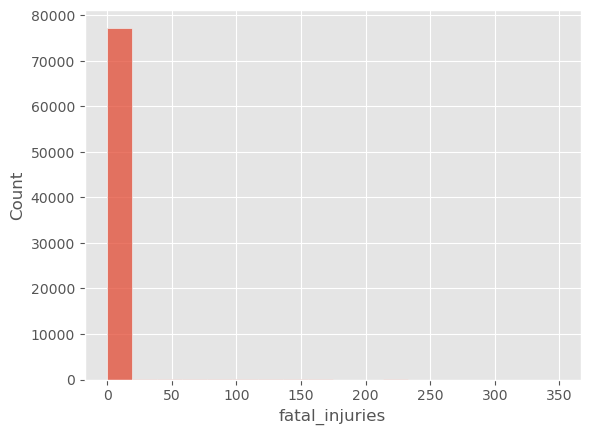

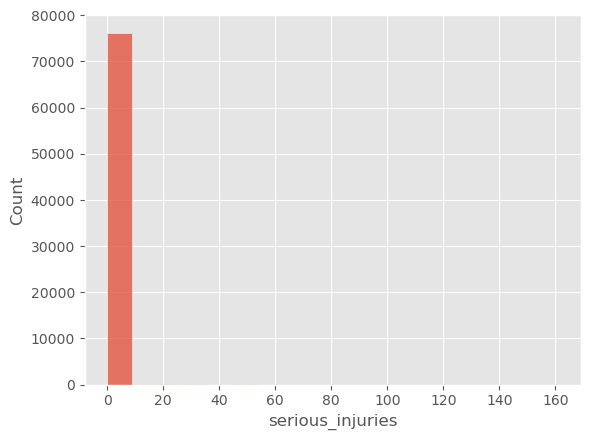

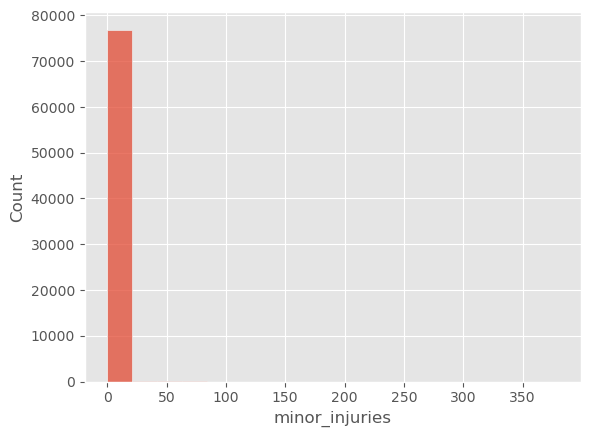

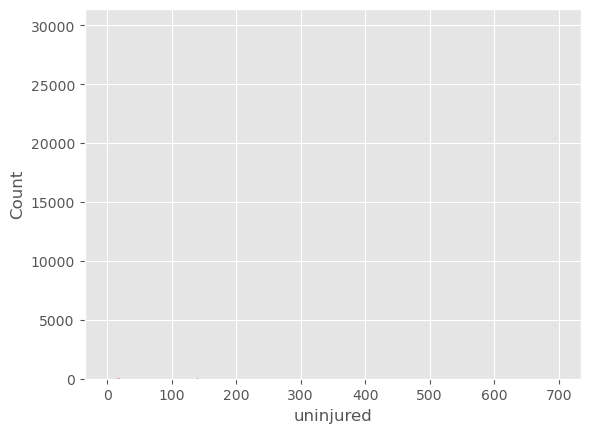

In [21]:
# Data distribution for numeric columns
for i in data.select_dtypes(include='number').columns:
    sns.histplot(data,x=i)
    plt.show()

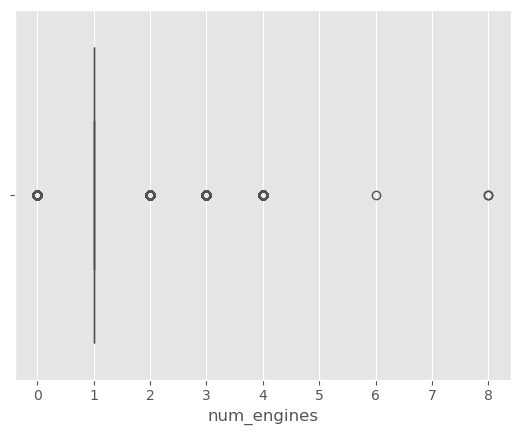

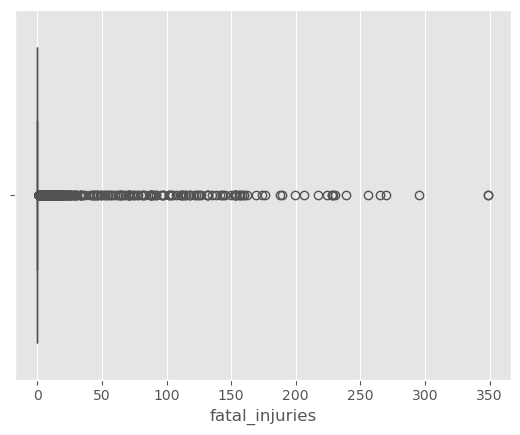

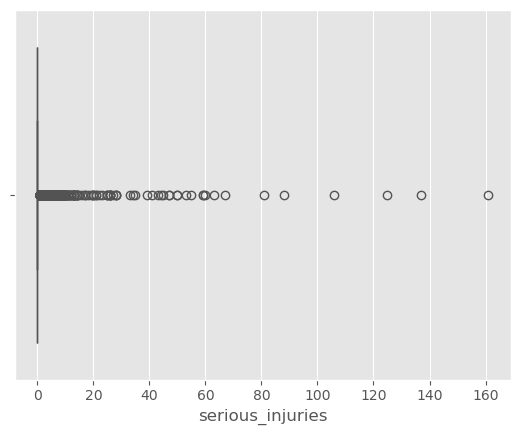

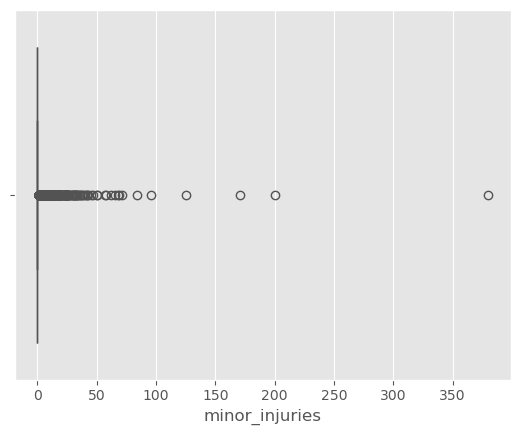

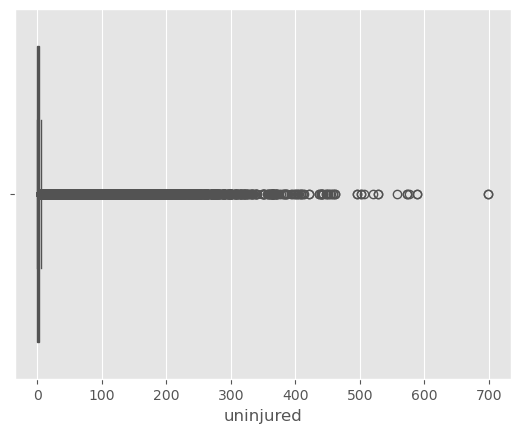

In [22]:
# Boxplot to identify outliers for numerical data
for i in data.select_dtypes(include='number').columns:
    sns.boxplot(data,x=i)
    plt.show()

In [23]:
# Data distribution for categorical columns
data.describe(include='object').T


,count,unique,top,freq
investigation_type,88889,2,Accident,85015
location,88837,27758,"ANCHORAGE, AK",434
country,88663,219,United States,82248
injury_severity,87889,109,Non-Fatal,67357
aircraft_damage,85695,4,Substantial,64148
aircraft_category,32287,15,Airplane,27617
make,88826,8237,Cessna,22227
model,88797,12318,152,2367
amateur_built,88787,2,No,80312
engine_type,81793,12,Reciprocating,69530


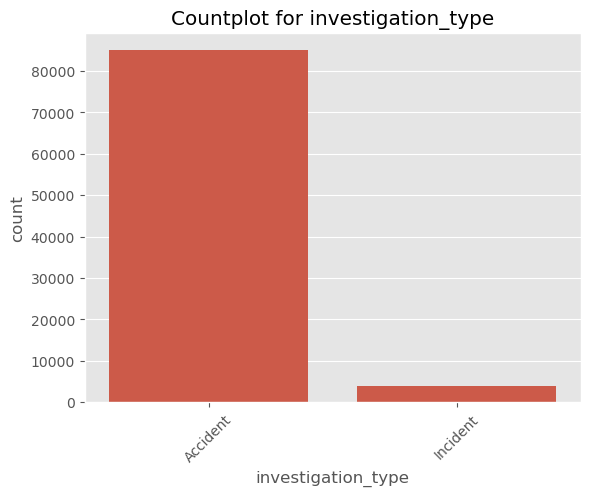

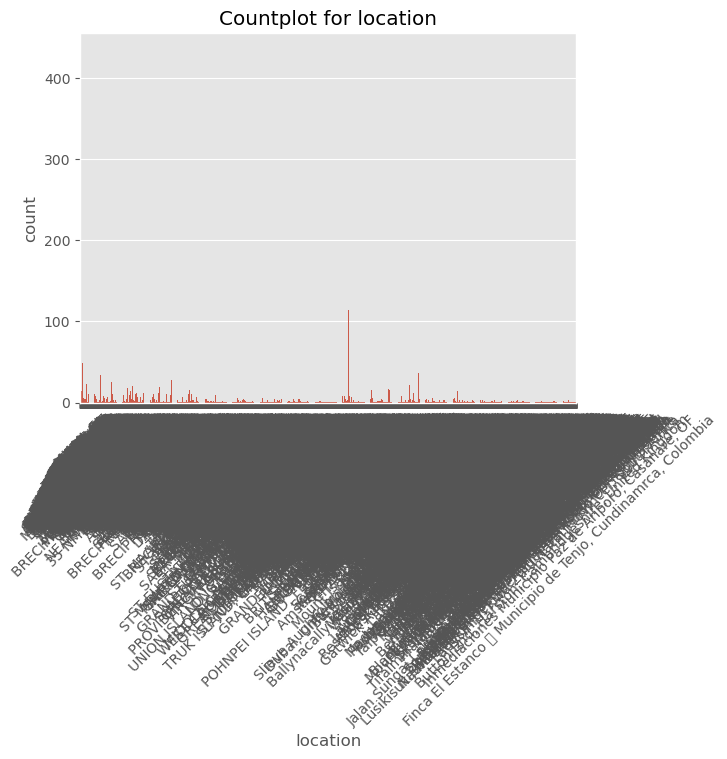

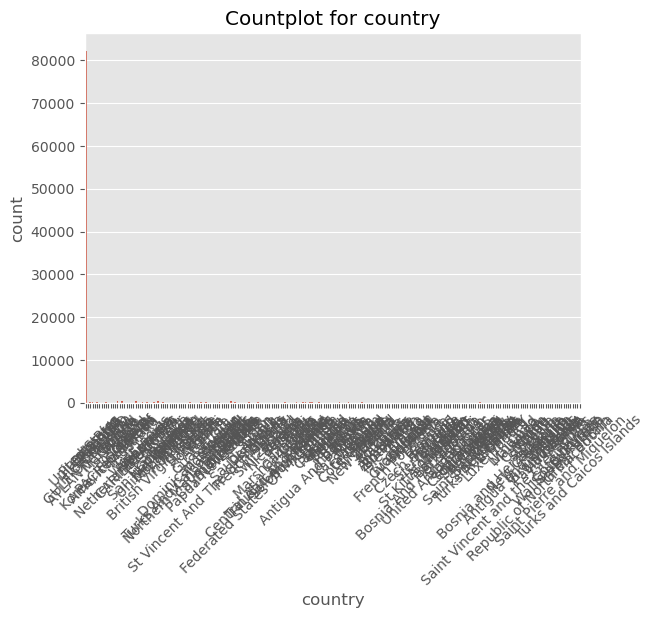

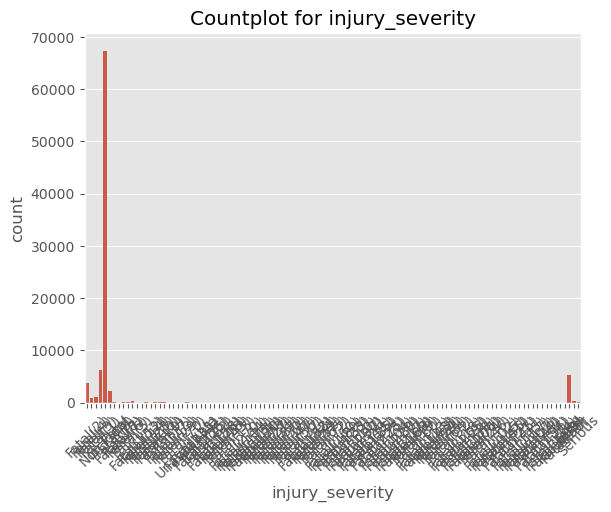

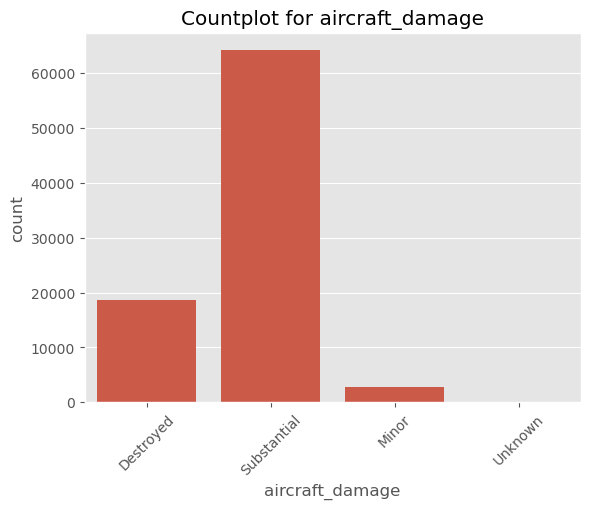

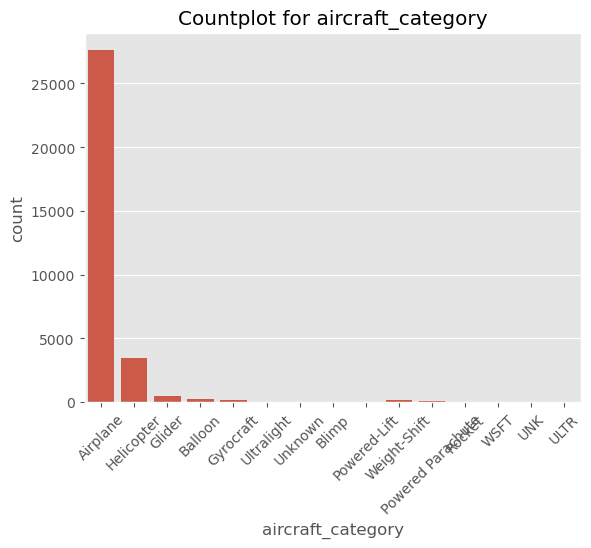

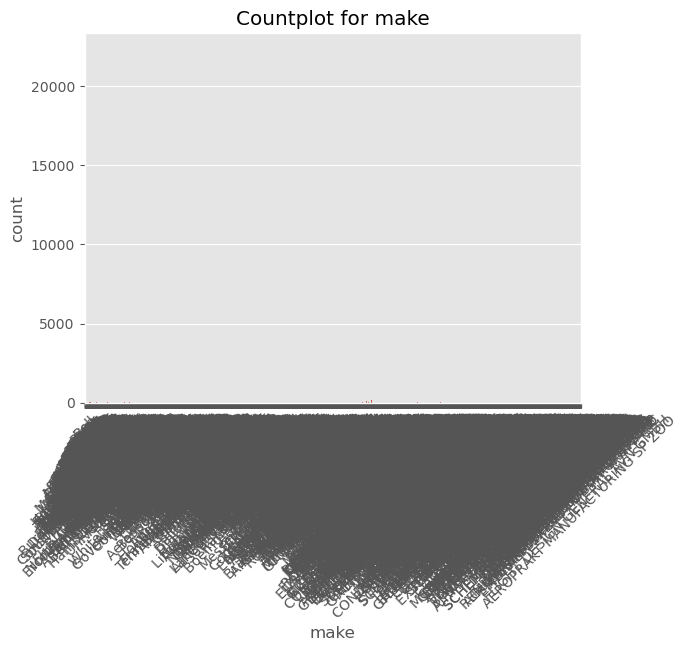

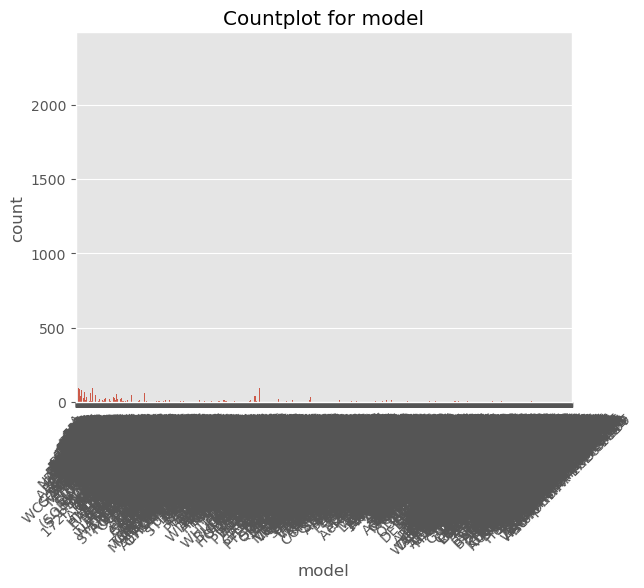

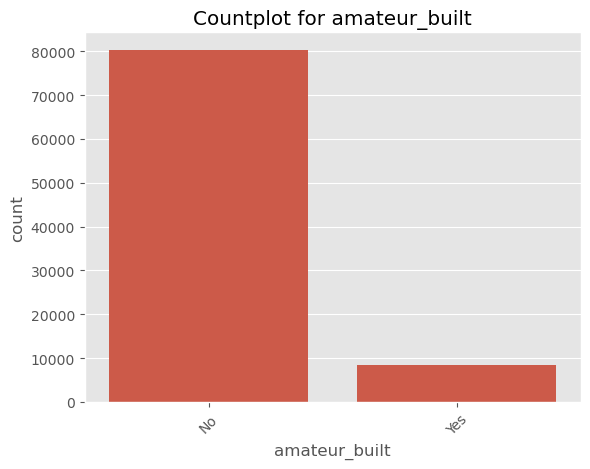

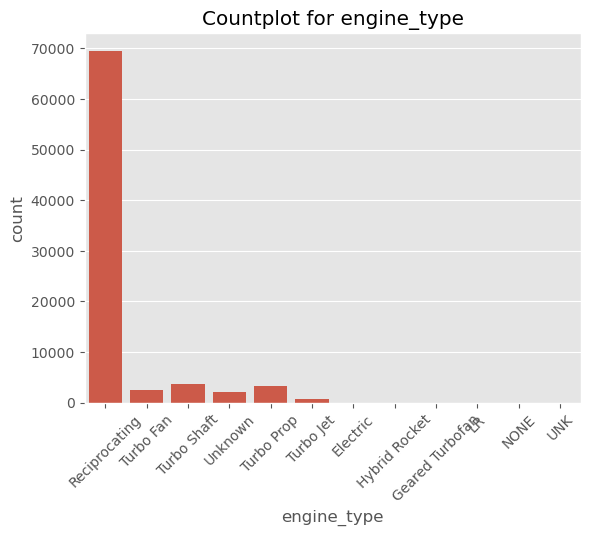

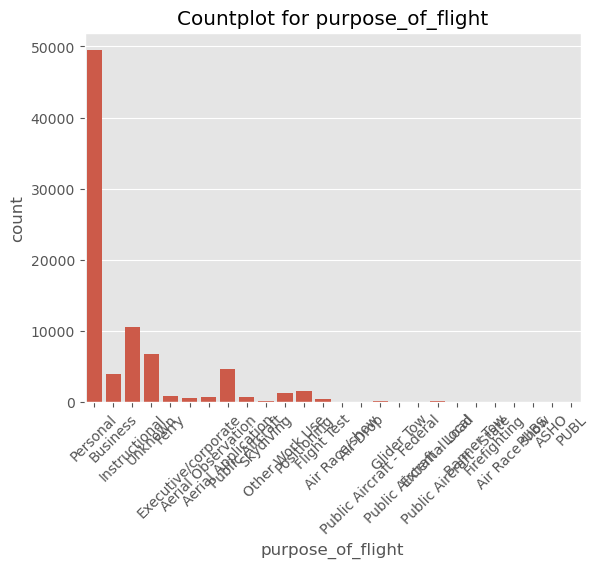

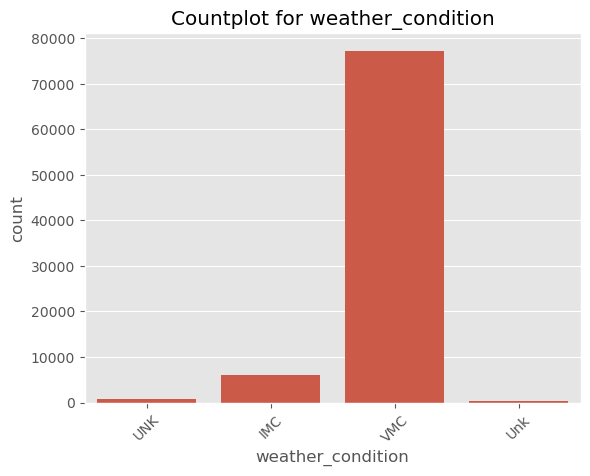

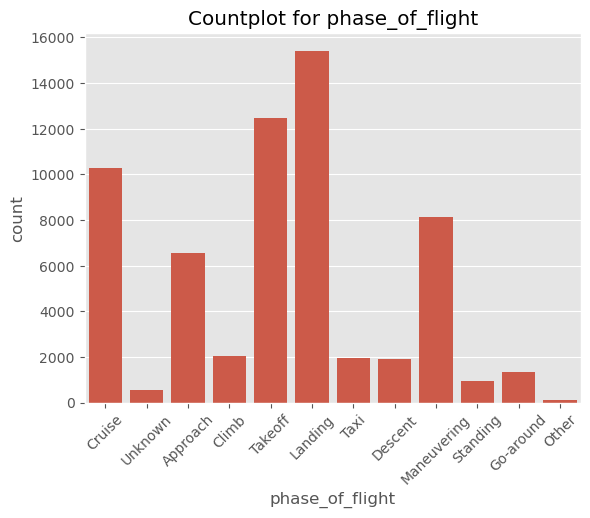

In [24]:
# Bar plot for the distribution of each column
for col in data.select_dtypes(include='object').columns:
    sns.countplot(data=data, x=col)
    plt.title(f"Countplot for {col}")
    plt.xticks(rotation=45)
    plt.show()

#### 2.3.1.2 Bivariate Analysis

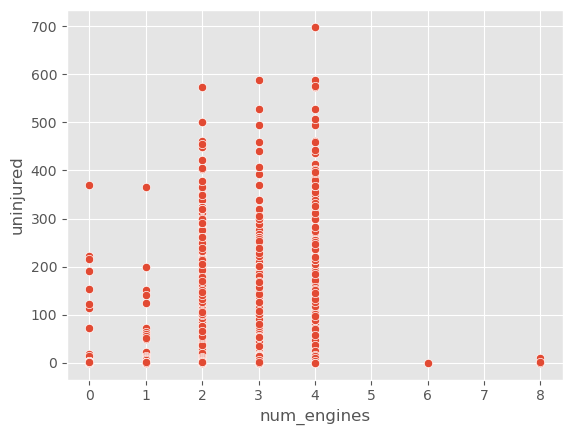

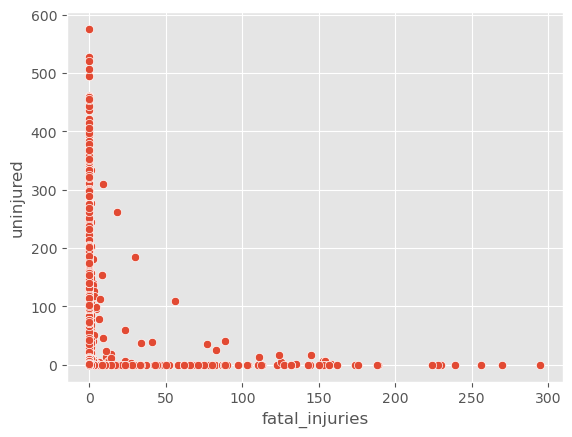

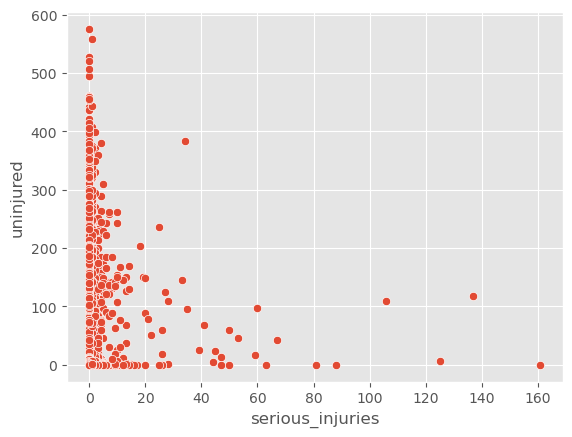

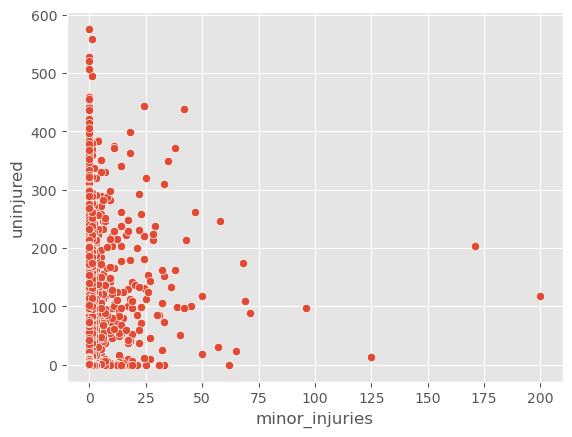

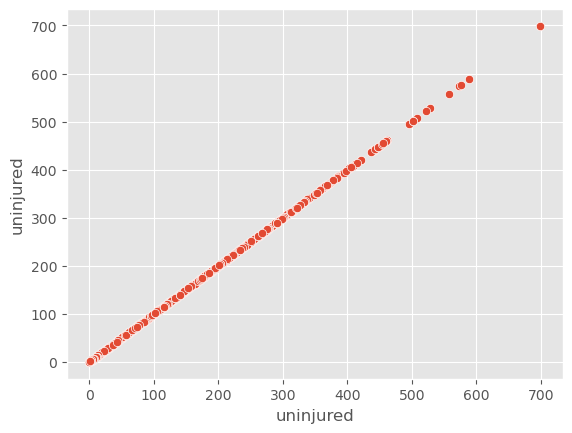

In [25]:
# Scatter plot to understand the relationship
for i in data.select_dtypes(include='number').columns:
    sns.scatterplot(data,x=i, y='uninjured')
    plt.show()

## 2.4 Imputing the missing values

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investigation_type  88889 non-null  object        
 1   event_date          88889 non-null  datetime64[ns]
 2   location            88837 non-null  object        
 3   country             88663 non-null  object        
 4   injury_severity     87889 non-null  object        
 5   aircraft_damage     85695 non-null  object        
 6   aircraft_category   32287 non-null  object        
 7   make                88826 non-null  object        
 8   model               88797 non-null  object        
 9   amateur_built       88787 non-null  object        
 10  num_engines         82805 non-null  float64       
 11  engine_type         81793 non-null  object        
 12  purpose_of_flight   82697 non-null  object        
 13  fatal_injuries      77488 non-null  float64   

In [12]:
# For numerical variables with median because they are all intergers
for i in data.select_dtypes(include='number').columns:
    median = data[i].median()
    data[i].fillna(median, inplace=True)

In [13]:
# Imputing for categorical variables with mode and unknown where necessary
mode_cols = ["make", "model", "injury_severity", "country"]

# Standardize string formats first
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].str.strip().str.title()
    data[col] = data[col].replace({
        "Unk": "Unknown",
        "N/A": "Unknown",
        "Na": "Unknown",
        "None": "Unknown",
        "UNKNOWN":"Unknown"
    })

# Combined imputation using IF–ELSE
for col in data.select_dtypes(include='object').columns:
    if col in mode_cols:
        mode_value = data[col].mode()[0]
        data[col].fillna(mode_value, inplace=True)
    else:
        data[col].fillna("Unknown", inplace=True)


In [14]:
data.isna().sum()

investigation_type    0
event_date            0
location              0
country               0
injury_severity       0
aircraft_damage       0
aircraft_category     0
make                  0
model                 0
amateur_built         0
num_engines           0
engine_type           0
purpose_of_flight     0
fatal_injuries        0
serious_injuries      0
minor_injuries        0
uninjured             0
weather_condition     0
phase_of_flight       0
dtype: int64

In [30]:
sorted(list(data['make'].unique()))



['107.5 Flying Corporation',
 '1200',
 '177Mf Llc',
 '1977 Colfer-Chan',
 '1St Ftr Gp',
 '2000 Mccoy',
 '2001 Mcgirl',
 '2003 Nash',
 '2007 Savage Air Llc',
 '2021Fx3 Llc',
 '3Xtrim',
 '5 Rivers Llc',
 '67 Flying Dutchman',
 '737',
 '777',
 '781569 Inc',
 '85 Manista',
 'A Pair Of Jacks',
 'A. H. Gettings',
 'A. Le Francois',
 'A. Schleicher Gmbh & Co.',
 'Aaa Aircraft Leasing',
 'Aaa Aircraft Llc',
 'Aardema Robert John',
 'Ab Sportine Aviacija',
 'Abbett Gerry',
 'Abbey Victor',
 'Abbott',
 'Abc',
 'Abernathy',
 'Abraham J G Ii/Erickson K',
 'Abrams',
 'Abrams/Nuding',
 'Abruzzo',
 "Ac Mfg & Dev'T Co",
 'Aces High',
 'Ackert',
 'Ackland Jeffrey Dean',
 'Acro',
 'Acro Sport',
 'Acroduster',
 'Adams',
 'Adams Balloon',
 'Adams Balloons Llc',
 'Adams Dennis Allen',
 'Adams Donald L',
 'Adams John R Jr',
 'Adams William C',
 'Adkins',
 'Adler',
 'Adolfson',
 'Adolphson',
 'Adrian Davis',
 'Adrian George W',
 'Advance Aviation',
 'Advanced Acft',
 'Advanced Aviation',
 'Advanced Technolog

In [31]:
data.make.value_counts()

make
Cessna                            27212
Piper                             14870
Beech                              5372
Boeing                             2745
Bell                               2722
Mooney                             1334
Robinson                           1230
Grumman                            1172
Bellanca                           1045
Hughes                              932
Schweizer                           773
Air Tractor                         691
Aeronca                             636
Mcdonnell Douglas                   608
Maule                               589
Champion                            519
Stinson                             439
Aero Commander                      429
De Havilland                        422
Luscombe                            414
Aerospatiale                        388
North American                      383
Taylorcraft                         383
Rockwell                            355
Hiller                             

In [15]:
# Standardizing the make column
# Strip extra spaces and unify case
data['make'] = data['make'].str.strip().str.title()

from rapidfuzz import process, fuzz

unique_makes = list(data['make'].unique())
standardized = {}

for make in unique_makes:
    # Find closest already standardized name
    match = process.extractOne(make, standardized.keys(), scorer=fuzz.token_sort_ratio)
    if match and match[1] > 90:  # threshold for similarity
        standardized[make] = match[0]  # map to the canonical name
    else:
        standardized[make] = make

data['make'] = data['make'].map(standardized)



My dataset is now clean and set for deeper analysis and visualizations. I have decided to keep some of the placeholders as they have valuable information about the data regarding to their respective columns and removing them or replacing them would have rendered my results biased. Summatively my clean data is as redered from here on.

# 3 EDA in Depth
## 3.1. Feature Engineering
Here i'll be combining several features to make sense of the futher analysis and also to make it easier to group the features to come up with a sensible interpretation of what is depicted in the dataset.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", rc={"figure.figsize": (10,8)})

# derived
data['year'] = data['event_date'].dt.year
data['total_injuries'] = data[['fatal_injuries','serious_injuries','minor_injuries']].sum(axis=1)
data['any_fatality'] = (data['fatal_injuries'].fillna(0) > 0).astype(int)

# severity score (simple): fatal=3, serious=2, minor=1, uninjured=0
data['severity_score'] = (data['fatal_injuries'].fillna(0)*3 +
                          data['serious_injuries'].fillna(0)*2 +
                          data['minor_injuries'].fillna(0)*1)


## 3.1 How is fatality rate trending over the years in the aviation industry?
Here we will find out how the trend has been over time

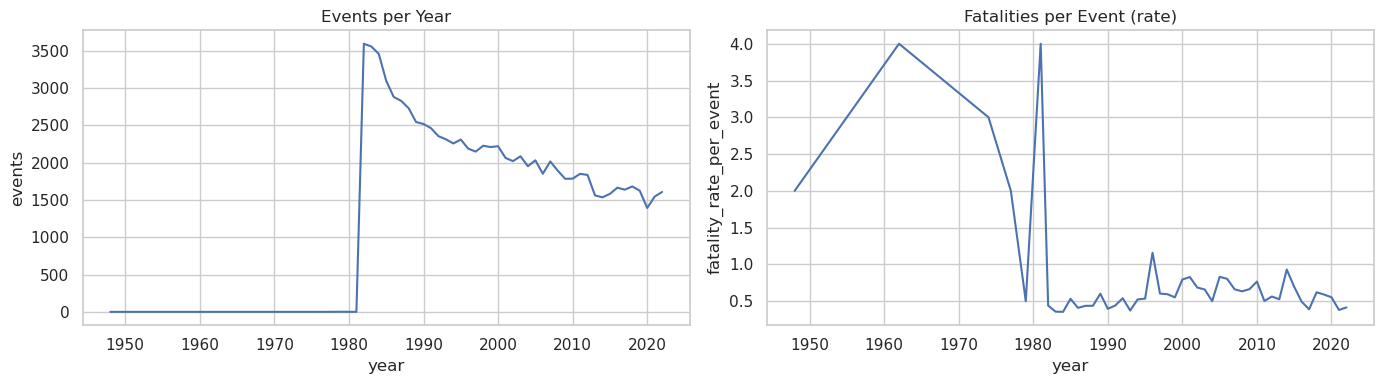

In [17]:
# counts per year
yearly = data.groupby('year').agg(
    events=('year','size'),
    fatalities=('fatal_injuries','sum'),
    fatal_events=('any_fatality','sum')
).reset_index()
yearly['fatality_rate_per_event'] = yearly['fatalities'] / yearly['events']

# plots
fig, ax = plt.subplots(1,2, figsize=(14,4))
sns.lineplot(data=yearly, x='year', y='events', ax=ax[0])
ax[0].set_title('Events per Year')
sns.lineplot(data=yearly, x='year', y='fatality_rate_per_event', ax=ax[1])
ax[1].set_title('Fatalities per Event (rate)')
plt.tight_layout()
plt.show()


The results above show a declining situation for events per year and spikes in the preceding years till 1981 in the fatalities graph and a more stable situation with lower events from 1983 onwards. This indicates safety improvements over the years since 1983 there one can prefer to invest in the latest models.

## 3.2 How are severe events?

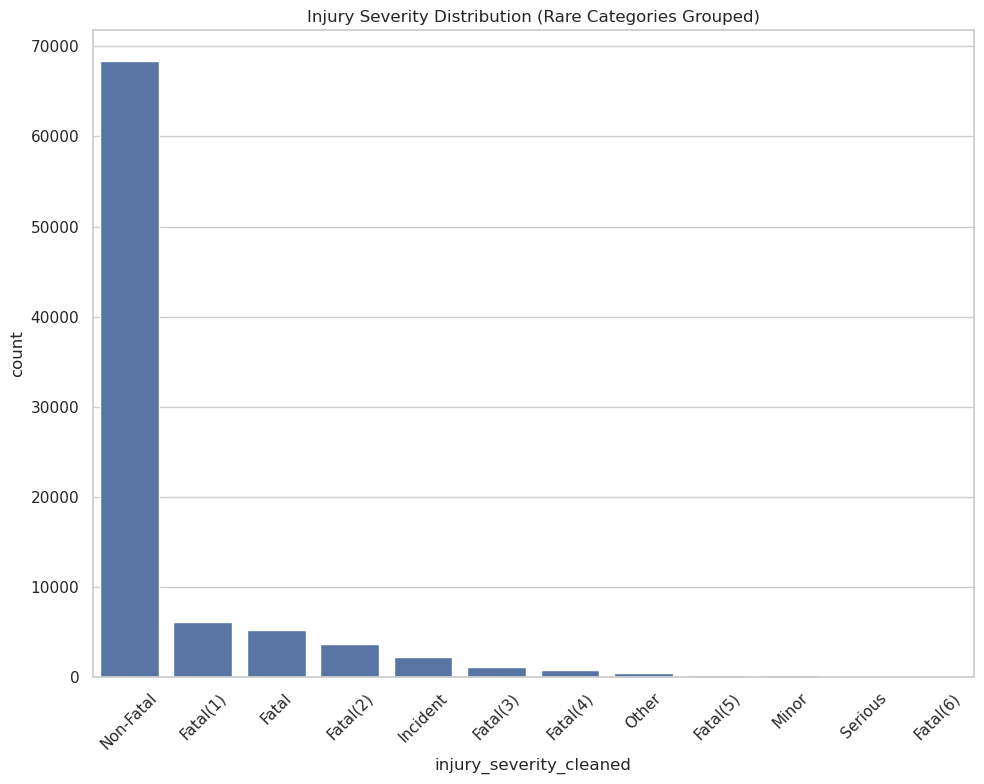

In [40]:
counts = data['injury_severity'].value_counts()
rare = counts[counts < 100].index  # threshold may be 20/50/100

data['injury_severity_cleaned'] = data['injury_severity'].replace(rare, 'Other')

order = data['injury_severity_cleaned'].value_counts().index

sns.countplot(
    data=data,
    x='injury_severity_cleaned',
    order=order
)
plt.title('Injury Severity Distribution (Rare Categories Grouped)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Non-fatal appears to be the most populated field in this case.A high non-fatal proportion favors lower insurance/compensation costs, high fatality share increases reputational and liability risk

## 3.3 Which phases produce the most events and most fatalities?
Phase of flight verses Severity

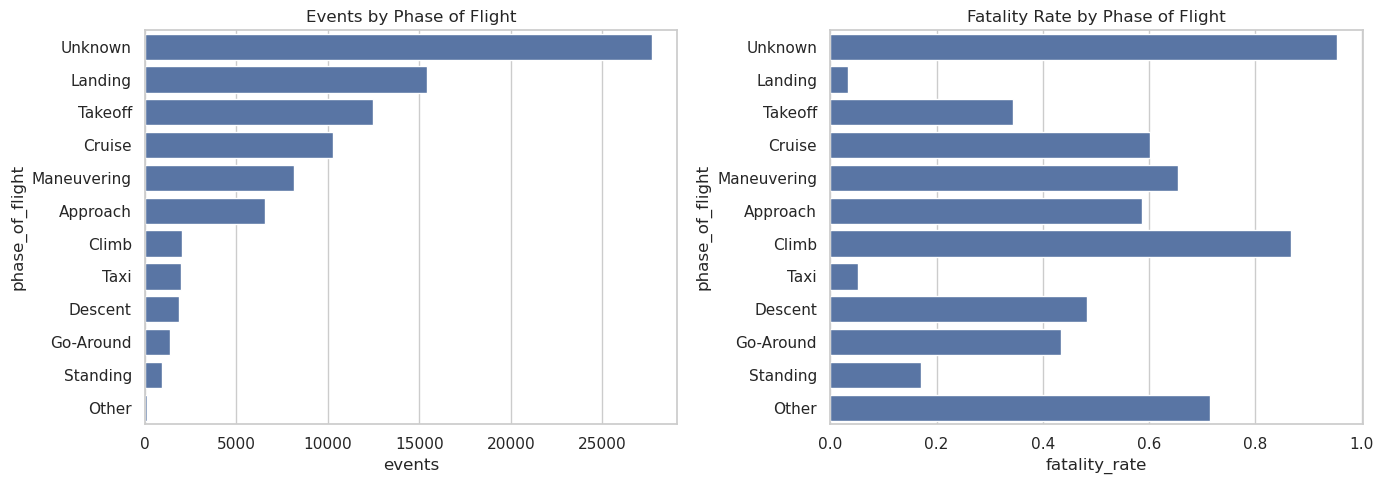

In [41]:
phase = data.groupby('phase_of_flight').agg(
    events =('phase_of_flight','size'),
    fatalities = ('fatal_injuries','sum'),
    fatal_events = ('any_fatality','sum'),
    mean_severity = ('severity_score','mean')
).sort_values('events',ascending=False).reset_index()

fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.barplot(data=phase, x='events', y='phase_of_flight', ax=ax[0])
ax[0].set_title('Events by Phase of Flight')
phase['fatality_rate'] = phase['fatalities'] / phase['events']
sns.barplot(data=phase, x='fatality_rate', y='phase_of_flight', ax=ax[1])
ax[1].set_title('Fatality Rate by Phase of Flight')
plt.tight_layout()
plt.show()

The unknown category is simply not known, had no records so we can ignore it for simple understanding. The results shows that landing takeoff, crise,manuvering and approach had the highest events recorded in a decreasing order. On the other hand each event observed din't lead to fatality therefore the order of fatalities recorded vary with climb being the lead.
Investors should prioritize operators with strong SOPs for landing, climb and othrs with adverse cases, runway infrastructure, and pilot training

## 3.4 Which wheather is assocciated with more severe outcomes?
Weather impact

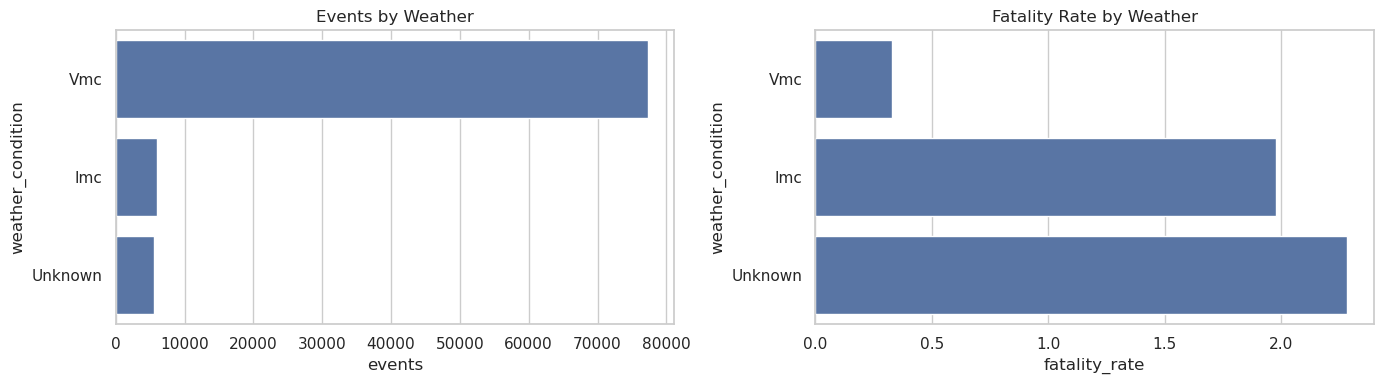

In [18]:
# compute proportion of fatal events per weather condition
weather = data.groupby('weather_condition').agg(
    events=('weather_condition','size'),
    fatalities=('fatal_injuries','sum')
).reset_index()
weather['fatality_rate'] = weather['fatalities']/weather['events']
weather = weather.sort_values('events', ascending=False)

# plot event counts and fatality rate
fig, ax = plt.subplots(1,2, figsize=(14,4))
sns.barplot(data=weather.head(12), x='events', y='weather_condition', ax=ax[0])
ax[0].set_title('Events by Weather')
sns.barplot(data=weather.head(12), x='fatality_rate', y='weather_condition', ax=ax[1])
ax[1].set_title('Fatality Rate by Weather')
plt.tight_layout()
plt.show()


Here we had two categories, the unknown had no specific belonging therefor it will be ignored while interpreting.
IMC shows higher fatality_rate but low counts which could translate to the need of IFR-capable aircraft and pilot training.
VMC has high counts but low fatality rate this translates to human/operational causes dominance.
Investors should consider investing in fleets with avionics appropriate to expected operating weather, for regions with frequent IMC, require IFR and FDM.

## 3.5 Which business lines are riskier
Purpose of flight VS severity

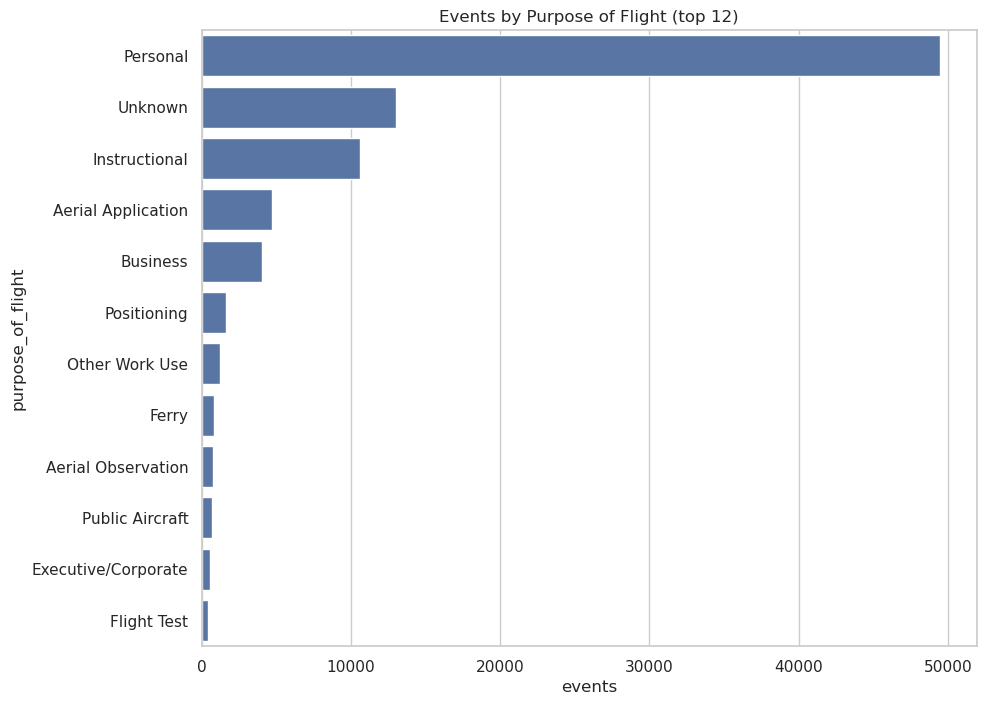

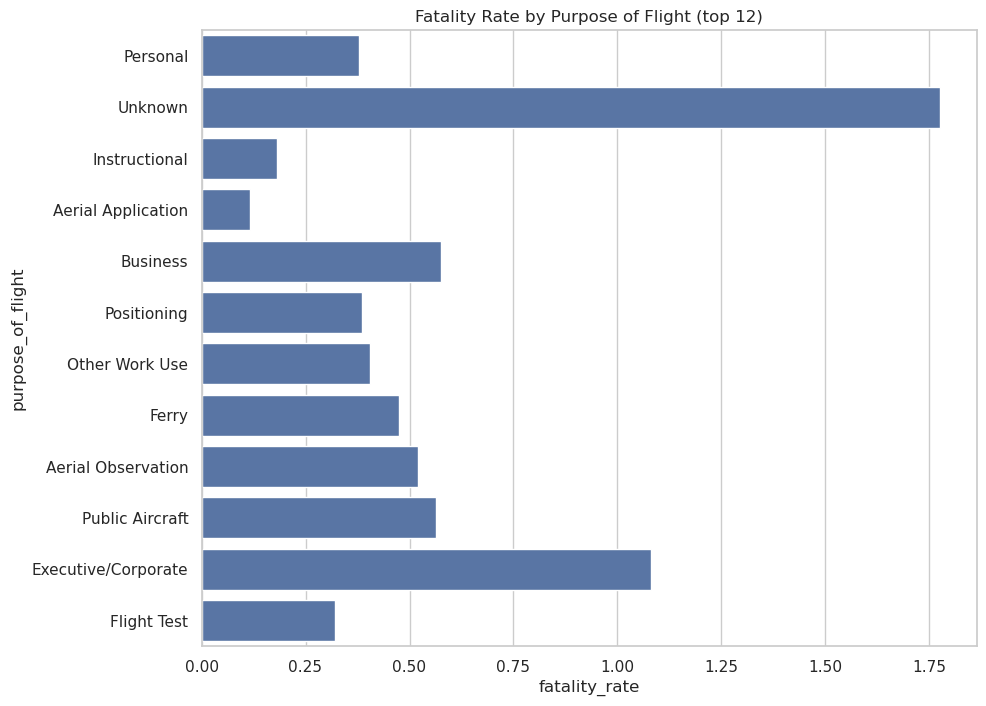

In [43]:
purpose = data.groupby('purpose_of_flight').agg(
    events=('purpose_of_flight','size'),
    fatalities=('fatal_injuries','sum')
).reset_index()
purpose['fatality_rate'] = purpose['fatalities']/purpose['events']
purpose = purpose.sort_values('events', ascending=False)

# top 12
sns.barplot(data=purpose.head(12), x='events', y='purpose_of_flight')
plt.title('Events by Purpose of Flight (top 12)')
plt.show()

sns.barplot(data=purpose.head(12), x='fatality_rate', y='purpose_of_flight')
plt.title('Fatality Rate by Purpose of Flight (top 12)')
plt.show()


Again no records relating to any specific field for the unknown hence it is not considered.
Personal,aerial application and Instructional shows a higher event counts while Corporate, business and public aircraft show  a higher severity.
For lower risk: favor scheduled commercial passenger or cargo operations, stable leasing or MRO businesses rather than those with high fatality rate and count of event.

## 3.6 a) Which models and makes are used often and whether they have high severity relative to frequencey.
Raw counts reflect popularity. To estimate risk, we compute fatality_rate per event for each make/model and prioritize those with both high rate and reasonable counts.

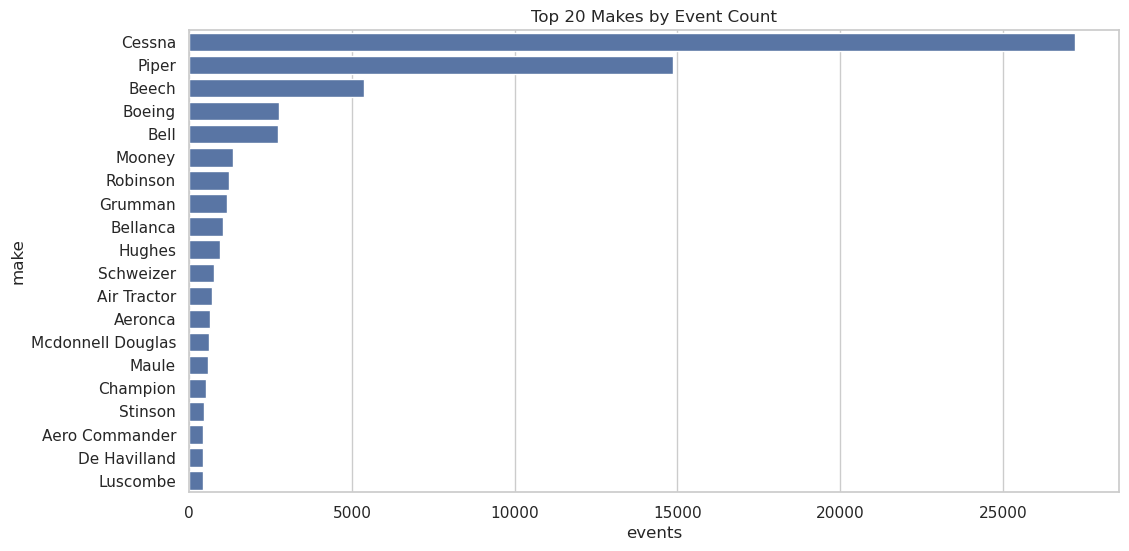

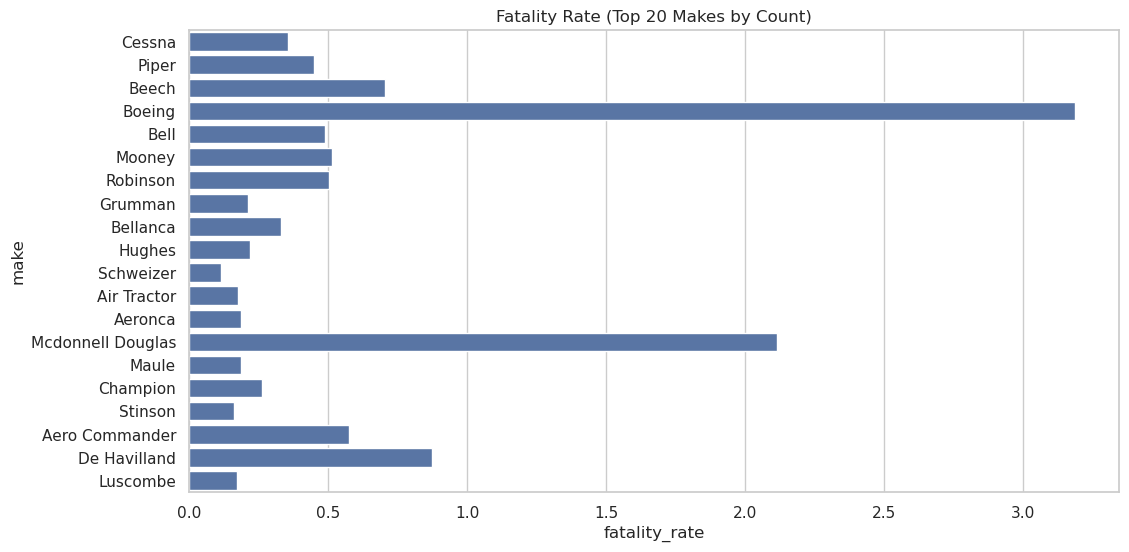

,model,make,events,fatalities,fatality_rate
2140,737-200,Boeing,53,906.0,17.094340
2916,A320,Airbus,85,283.0,3.329412
2169,737-300,Boeing,51,167.0,3.274510
2104,737,Boeing,489,1348.0,2.756646
2355,767,Boeing,68,128.0,1.882353
687,200,Beech,86,126.0,1.465116
834,208,Cessna,103,143.0,1.388350
883,212,Bell,53,62.0,1.169811
837,208B,Cessna,189,214.0,1.132275
1507,421C,Cessna,131,145.0,1.106870


In [20]:
# Make level
make_stats = data.groupby('make').agg(
    events=('make','size'),
    fatalities=('fatal_injuries','sum')
).reset_index()
make_stats['fatality_rate'] = make_stats['fatalities']/make_stats['events']
make_stats_sorted = make_stats.sort_values(['events'], ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(data=make_stats_sorted, x='events', y='make')
plt.title('Top 20 Makes by Event Count')
plt.show()

# Plot fatality rate for those top20
plt.figure(figsize=(12,6))
sns.barplot(data=make_stats_sorted, x='fatality_rate', y='make')
plt.title('Fatality Rate (Top 20 Makes by Count)')
plt.show()

# Model-level top 15 by events and fatality rate
model_stats = data.groupby(['model','make']).agg(events=('model','size'), fatalities=('fatal_injuries','sum')).reset_index()
model_stats = model_stats[model_stats['events']>=50]  # focus on reasonably represented models
model_stats['fatality_rate'] = model_stats['fatalities']/model_stats['events']
model_stats.sort_values('fatality_rate', ascending=False).head(15)


The results above shows that Boeing of model 737-200 has the highest fatality rate at ~ 17% followed by airbus.
Investors should avoid the models associated with with high fatality as it results to incresed losses.

##  b) Which makes/models have the highest severity in each phase?

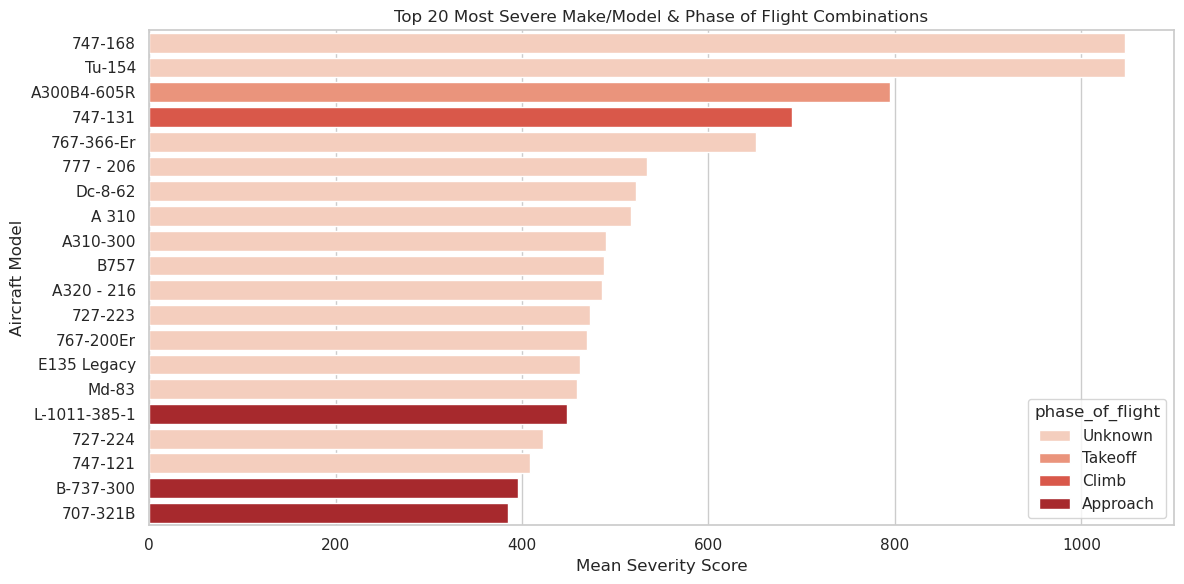

In [23]:
df_phase = data.groupby(["make", "model", "phase_of_flight"])["severity_score"].mean().reset_index()

top_severe = df_phase.sort_values("severity_score", ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_severe,
    x="severity_score",
    y="model",
    hue="phase_of_flight",
    palette="Reds"
)
plt.title("Top 20 Most Severe Make/Model & Phase of Flight Combinations")
plt.xlabel("Mean Severity Score")
plt.ylabel("Aircraft Model")
plt.tight_layout()
plt.show()


Most appears to be unknown phase with the pale pink. 
Popular models dominate raw counts, inspect fatality rate to detect models with unusually high severity like leading on the row.
Prefer platforms with low fatality rates and strong MRO/backlog support, avoid niche models with poor support or high severity ratios.

## 3.7 Does number of engine and type of engine have an effect of fatality rates?


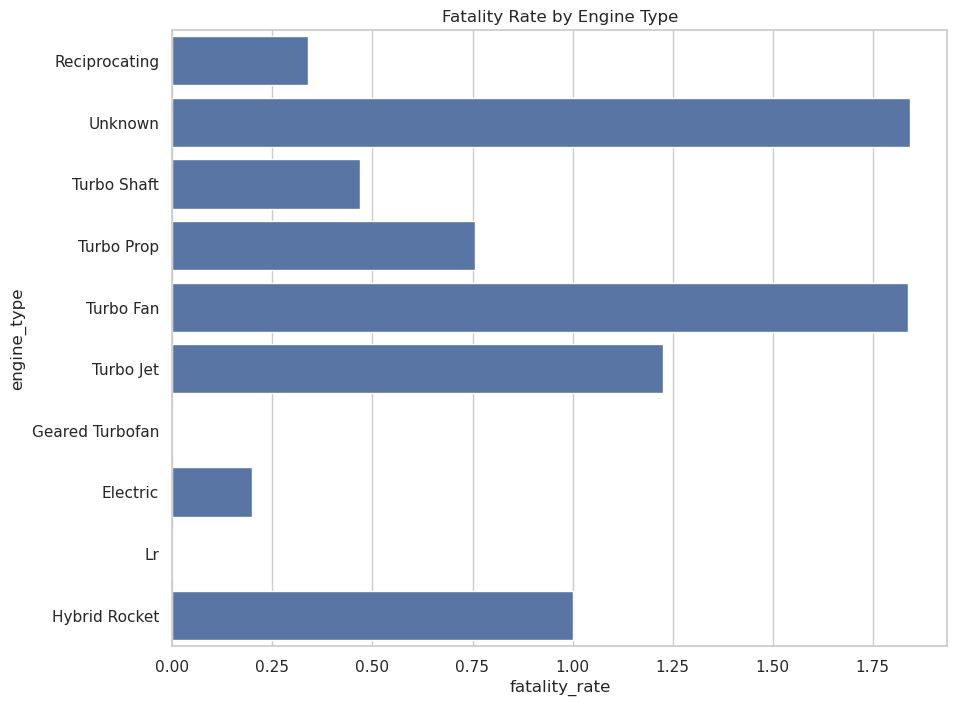

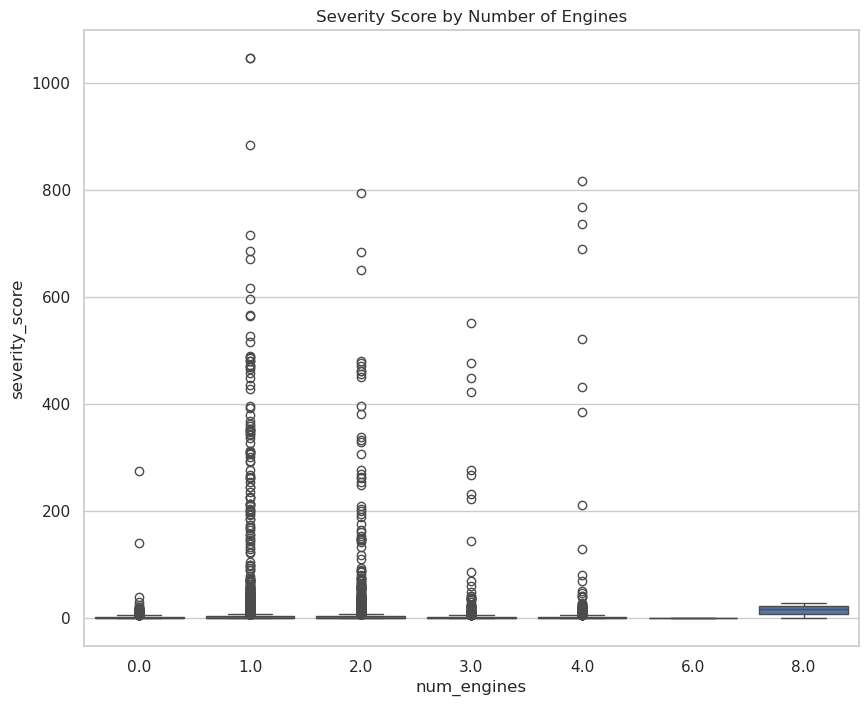

In [45]:
engine = data.groupby('engine_type').agg(events=('engine_type','size'), fatalities=('fatal_injuries','sum')).reset_index()
engine['fatality_rate'] = engine['fatalities']/engine['events']
sns.barplot(data=engine.sort_values('events',ascending=False), x='fatality_rate', y='engine_type')
plt.title('Fatality Rate by Engine Type')
plt.show()

# number of engines distribution
sns.boxplot(data=data, x='num_engines', y='severity_score')
plt.title('Severity Score by Number of Engines')
plt.show()


Multi-engine and Lr/Electric seem to have better survivability in many operations. Turbo fan/turbo jet/hybrid rocket show a higher severity.
For passenger/cargo operations pick Lr/Electric, for low-cost/training, ensure rigorous maintenance plans.

## 3.8 Does geographic pose a relative risk?
Geographic summary country level

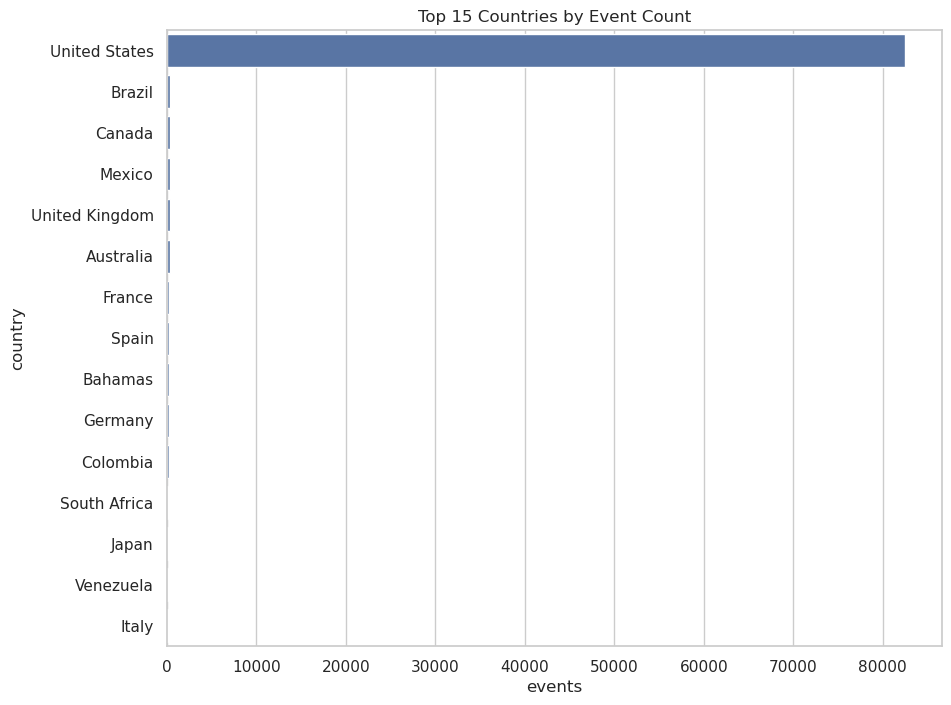

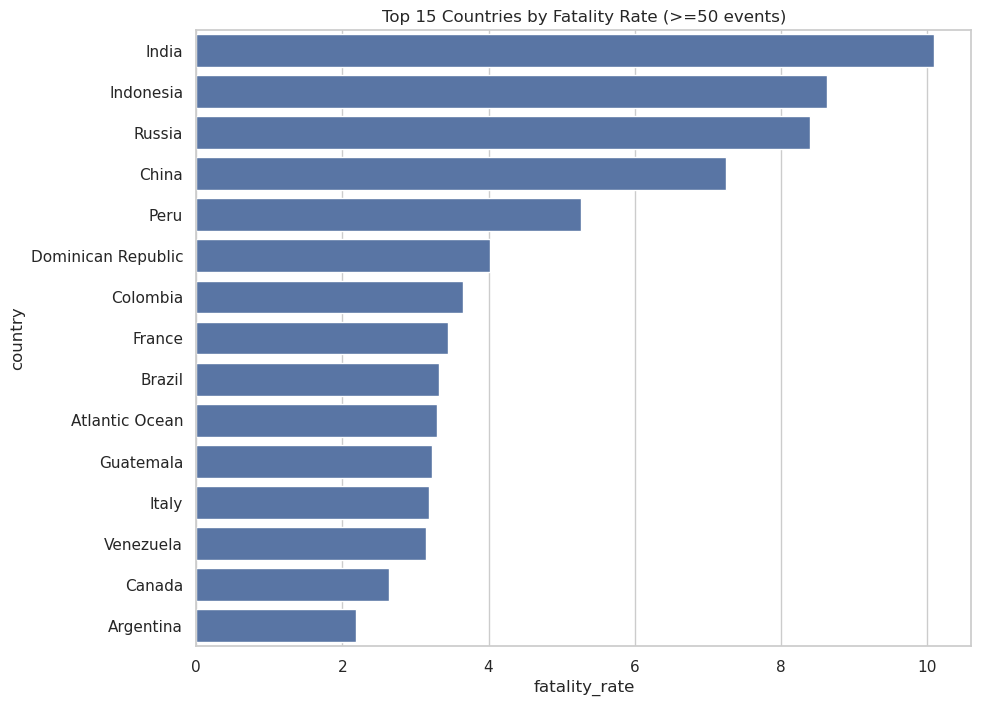

In [46]:
country = data.groupby('country').agg(events=('country','size'), fatalities=('fatal_injuries','sum')).reset_index()
country['fatality_rate'] = country['fatalities']/country['events']
# show top 15 by events and top 15 by fatality rate (only countries with >=50 events)
top_events = country.sort_values('events', ascending=False).head(15)
risky_countries = country[country['events']>=50].sort_values('fatality_rate', ascending=False).head(15)

sns.barplot(data=top_events, x='events', y='country')
plt.title('Top 15 Countries by Event Count')
plt.show()

sns.barplot(data=risky_countries, x='fatality_rate', y='country')
plt.title('Top 15 Countries by Fatality Rate (>=50 events)')
plt.show()


High event counts often occur in countries with lots of flight activity in this case the United States. High fatality_rate may flag poor infrastructure or oversight.
For lower regulatory risk, prefer investments in countries with low fatality rates and transparent reporting. For high-return plays in riskier countries, require stronger covenants, higher insurance, or JV with local partners.

## 3.9 How does make and purpose of flight relate to severity?

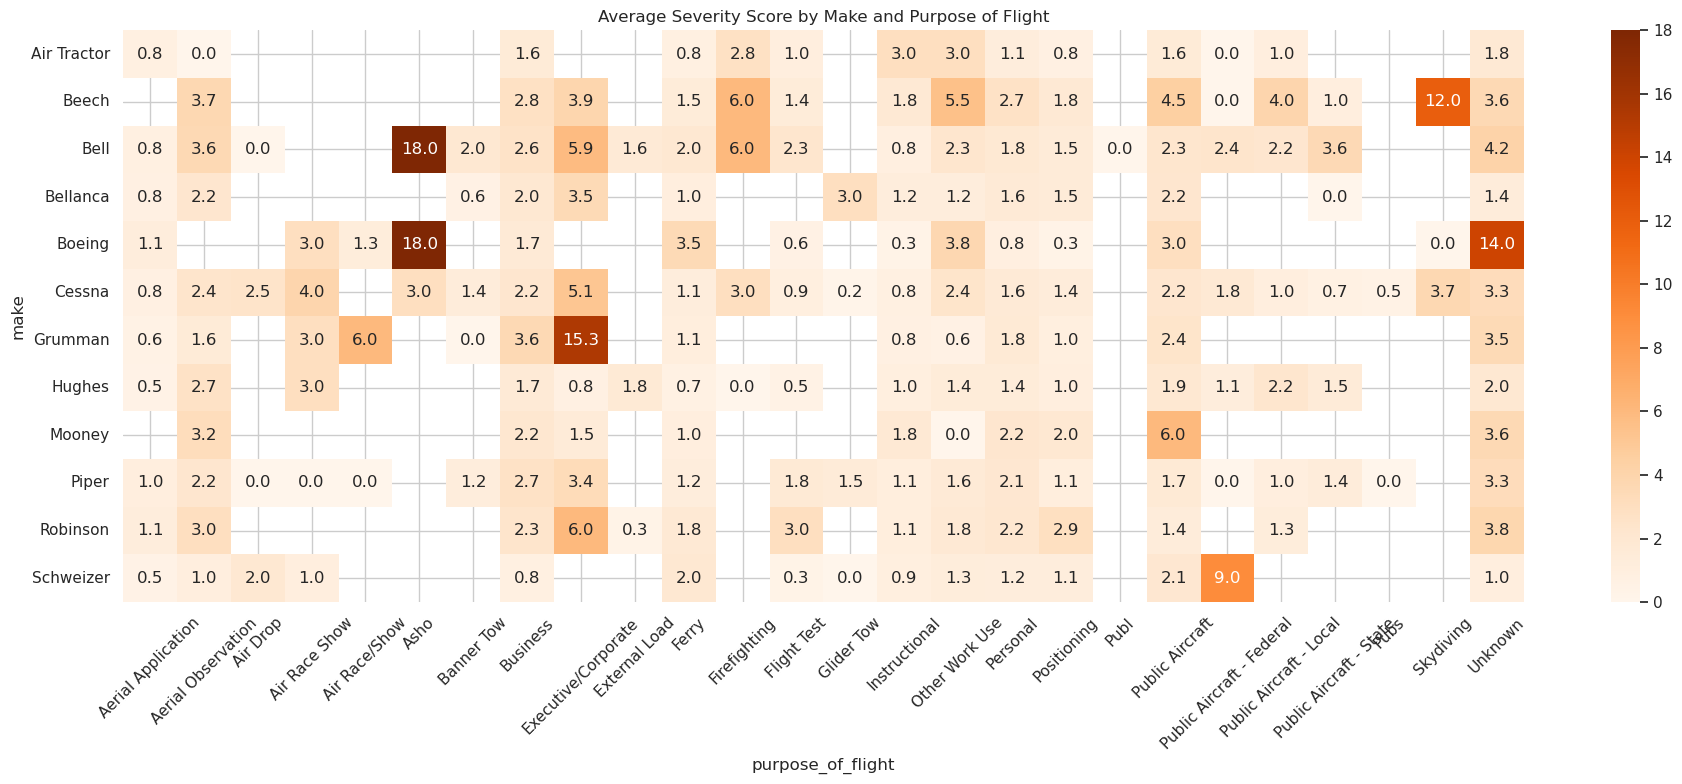

In [30]:
top_makes = data['make'].value_counts().nlargest(12).index
df_make = data[data['make'].isin(top_makes)]

pivot_make = df_make.pivot_table(
    index="make",
    columns="purpose_of_flight",
    values="severity_score",
    aggfunc="mean"
)

plt.figure(figsize=(19,8))
sns.heatmap(pivot_make, annot=True, cmap="Oranges", fmt=".1f")
plt.title("Average Severity Score by Make and Purpose of Flight")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The heatmap above shows severity score by make and purpose of flight where ASHO, corporate and skydiving seem to show more than 10 cases on average. An investor should consider a manufacture with the lowest fatality count depending on the nature of flight.

## 3.10 Does amature build have a relationship with purpose and severity?


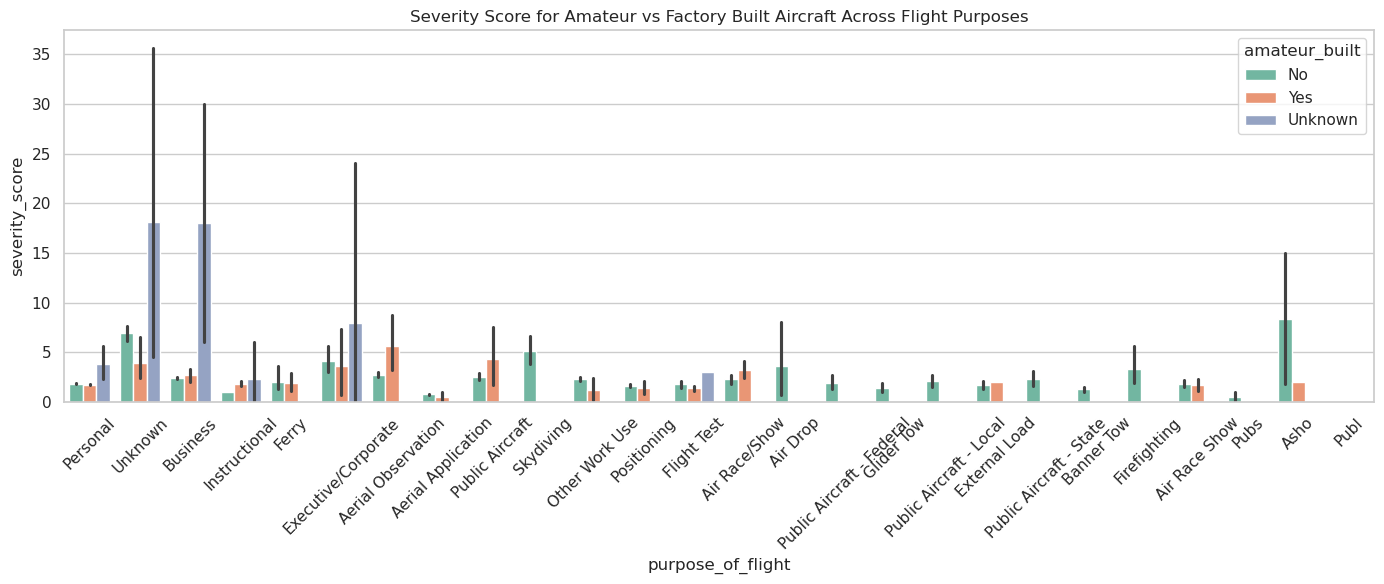

In [36]:
plt.figure(figsize=(14,6))
sns.barplot(
    data=data,
    x="purpose_of_flight",
    y="severity_score",
    hue="amateur_built",
    palette="Set2"
)
plt.xticks(rotation=45)
plt.title("Severity Score for Amateur vs Factory Built Aircraft Across Flight Purposes")
plt.tight_layout()
plt.show()


There seem no huge difference between the amature build and factory build only Asho seem to have a high severity score overrallwhich is about 8. Another observation made is that amature build is not used in some cases, probably due to fear of high risk.

## 3.11 what is the location and weather relation in comparison to severity?

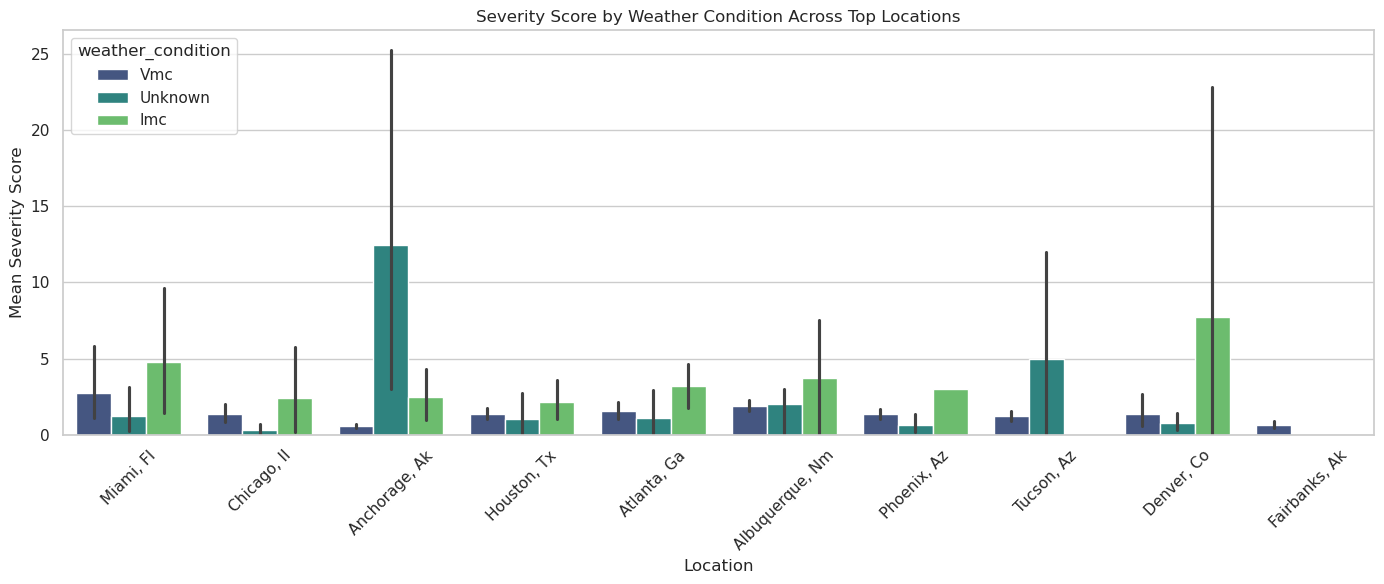

In [53]:
top_locations = data['location'].value_counts().nlargest(10).index
df_loc = data[data['location'].isin(top_locations)]
plt.figure(figsize=(14,6))
sns.barplot(
    data=df_loc,
    x="location",
    y="severity_score",
    hue="weather_condition",
    palette="viridis"
)
plt.title("Severity Score by Weather Condition Across Top Locations")
plt.xlabel("Location")
plt.ylabel("Mean Severity Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3.12 Are make, engine type and damage related?

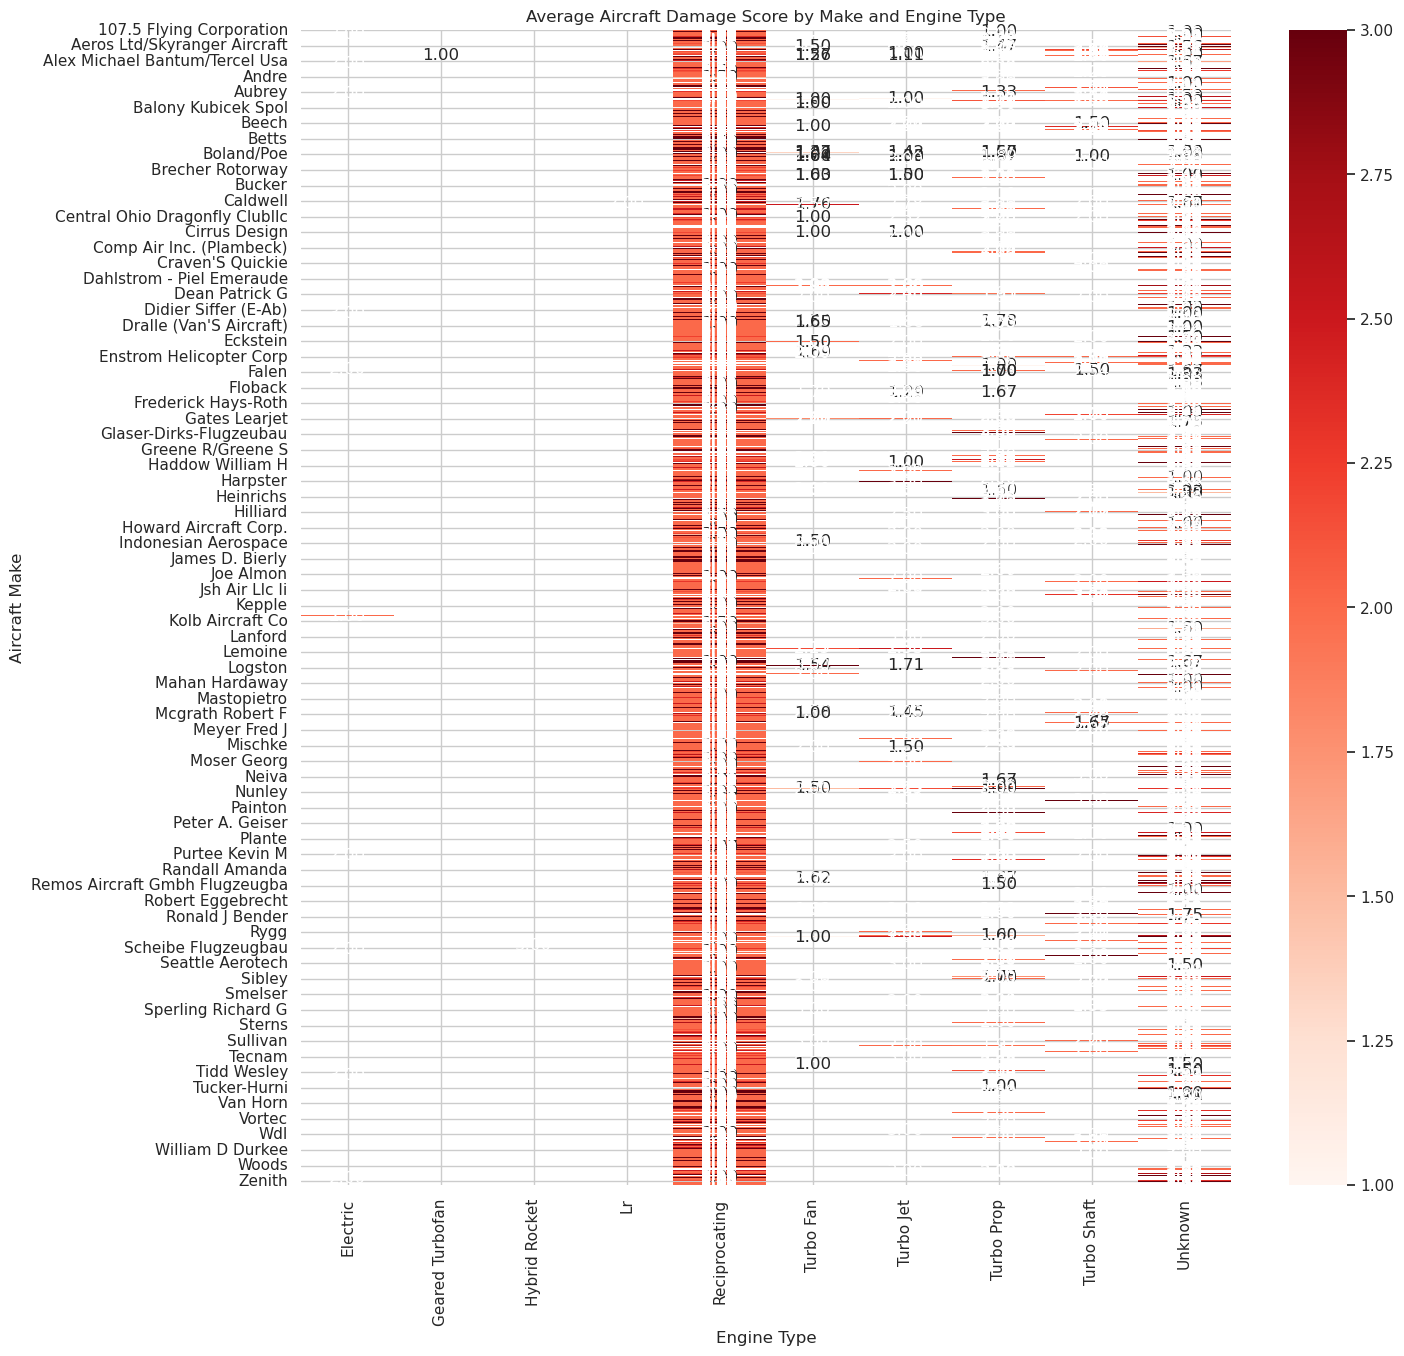

In [60]:
damage_map = {
    "Destroyed": 3,
    "Substantial": 2,
    "Minor": 1,
    "None": 0
}

data['damage_score'] = data['aircraft_damage'].map(damage_map)


pivot = data.pivot_table(
    index='make',
    columns='engine_type',
    values='damage_score',
    aggfunc='mean'
)

plt.figure(figsize=(15,15))
sns.heatmap(
    pivot,
    cmap='Reds',
    annot=True,
    fmt=".2f"
)
plt.title("Average Aircraft Damage Score by Make and Engine Type")
plt.xlabel("Engine Type")
plt.ylabel("Aircraft Make")
plt.show()



## 3.13  Weather condition, make and fatality rate relation

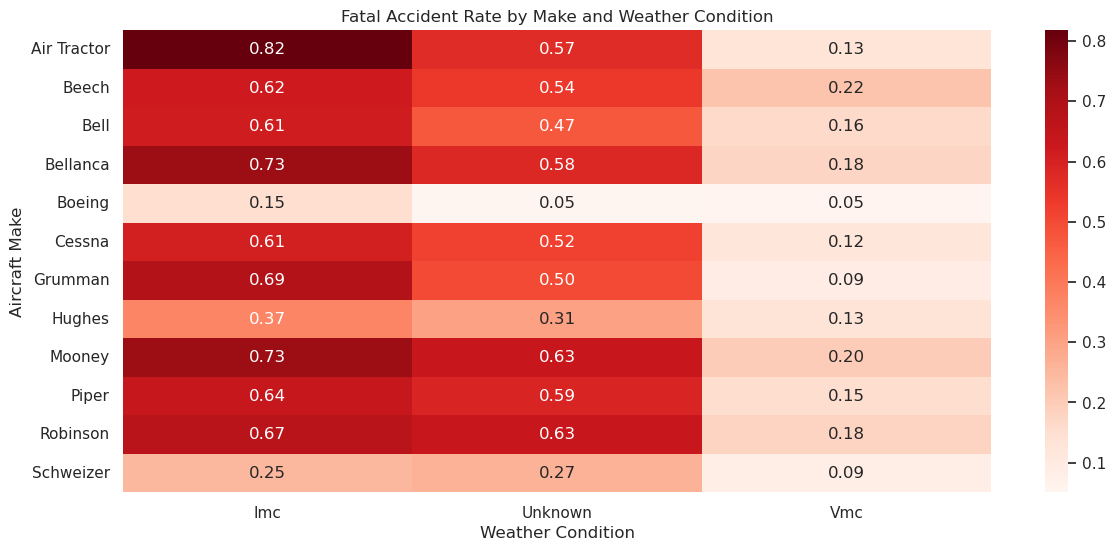

In [61]:
df_make['fatal_flag'] = (df_make['fatal_injuries'].fillna(0) > 0).astype(int)

fatal_pivot = df_make.pivot_table(
    index='make',
    columns='weather_condition',
    values='fatal_flag',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))
sns.heatmap(
    fatal_pivot,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)
plt.title("Fatal Accident Rate by Make and Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Aircraft Make")
plt.show()


IMC seem to have more fatalities compared to VMC with air tractor, bellanca and grumman being the most affected makes in this situation. investors should consider the makes with reduced risks for this weather condition.

## 3.14 Does make, weather  and phase of flight have a relation in terms of falatiliy

In [47]:
pivot = data.pivot_table(index='make', columns='phase_of_flight', values='fatal_injuries', aggfunc='sum', fill_value=0)
# show top makes by total fatal injuries
pivot['total_fatal'] = pivot.sum(axis=1)
pivot.sort_values('total_fatal', ascending=False).head(10)


phase_of_flight,Approach,Climb,Cruise,Descent,Go-Around,Landing,Maneuvering,Other,Standing,Takeoff,Taxi,Unknown,total_fatal
make,,,,,,,,,,,,,
Cessna,870.0,455.0,1823.0,244.0,177.0,115.0,1424.0,13.0,33.0,979.0,10.0,3560.0,9703.0
Boeing,471.0,241.0,271.0,0.0,0.0,37.0,23.0,0.0,8.0,260.0,2.0,7435.0,8748.0
Piper,700.0,359.0,1506.0,180.0,154.0,93.0,813.0,6.0,11.0,761.0,8.0,2098.0,6689.0
Beech,535.0,203.0,616.0,135.0,128.0,55.0,327.0,3.0,7.0,504.0,2.0,1269.0,3784.0
Bell,43.0,7.0,246.0,17.0,4.0,10.0,214.0,2.0,13.0,58.0,2.0,716.0,1332.0
Airbus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1325.0,1325.0
Mcdonnell Douglas,7.0,1.0,123.0,83.0,0.0,14.0,21.0,1.0,4.0,197.0,9.0,826.0,1286.0
Airbus Industrie,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,265.0,1.0,907.0,1174.0
Douglas,4.0,115.0,138.0,3.0,41.0,2.0,10.0,0.0,0.0,79.0,0.0,592.0,984.0


Shows which makes have fatal events concentrated in particular phases e.g,landing.
If a manufacturer/model shows phase-specific vulnerabilities, require extra maintenance checks / pilot SOP changes.

In [62]:
risk_summary = data.groupby([
    "purpose_of_flight",
    "location",
    "amateur_built",
    "make",
    "model",
    "engine_type"
]).agg(
    mean_severity=("severity_score", "mean"),
    count_events=("severity_score", "count")
).reset_index()

risk_summary["risk_level"] = pd.cut(
    risk_summary["mean_severity"],
    bins=[0, 0.5, 1.5, 2.5, 3],
    labels=["Low", "Moderate", "High", "Critical"]
)


# 4 Recommendations and Conclusions
- Prefer investments in commercial (scheduled) operations, leasing, MRO, or airports rather than personal / corporation segments. (Supported by purpose_of_flight and severity analysis.)

- Fleet selection: prioritize makes/models with low fatality_rate per event and large installed base (Cessna/Boeing/Piper/etc. as appropriate for the segment). Avoid niche models with high fatality rates or sparse MRO support.

- Operational risk controls: require SOPs and training focused on approach/landing and takeoff procedures; mandate Flight Data Monitoring (FDM) for continuous safety feedback. (Supported by phase_of_flight results.)

- Avionics and weather mitigation: in regions with non-trivial IMC events/fatality rates, require IFR-capable avionics and recurrent IMC training. (Weather analysis.)

- Geographic risk management: prefer jurisdictions with low fatality_rate and transparent reporting. For investments in higher-risk countries, add contractual protections: higher insurance, joint ventures, and stricter maintenance covenants.

- Maintenance and engine strategy: for passenger/cargo operations favor Lr and Electric engines, for training/flying clubs accept reciprocating but ensure elevated maintenance reserves and structured SOPs.

- Insurance and contractual protections: set premiums/escrows based on modeled fatality risk by phase/purpose/make and require material safety KPIs in investment covenants.

## 4.1 Conclusions
The analysis shows that aviation accident severity is strongly influenced by aircraft characteristics, operational context, and environmental conditions. Single-engine and amateur-built aircraft consistently exhibit higher fatality proportions, mainly due to lower redundancy and limited protection during critical failures. Weather factors, particularly poor visibility, wind, and adverse precipitation, increase the likelihood of serious outcomes, especially during takeoff, landing, and approach phases, where pilot workload and error sensitivity are highest. Certain makes and models also show clustering of fatal accidents, often reflecting differences in design maturity, aircraft age, and operational use cases rather than inherent defects.

Overall, the project demonstrates that no single factor determines the risk; instead, accident severity is multi-factorial, arising from interacting elements of aircraft type, flight phase, weather, and operational practices. These findings highlight the value of investing in modern, multi-engine, certified aircraft; strengthening weather-related decision protocols; and ensuring rigorous maintenance and pilot training. Implementing these evidence-based safeguards can meaningfully reduce fatal outcomes and guide more informed aviation investment decisions.

## 4.2 Next Steps
- Causality caution: these are association analyses, they do not prove causation. Combine with operational audits and expert review.
- Ideally normalize counts by exposures (flight hours or departures). If you can get flight-hour data for operators/regions/models, compute event rates per 100k flight-hours.
- Build a logistic model predicting any_fatality using phase_of_flight, weather_condition, purpose_of_flight, make/model features, engine_type, produce marginal effects and risk scores by operator/fleet.